In [188]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE  # For handling imbalanced data if needed
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set up visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
%matplotlib inline

In [189]:
# Cell 2A: Load and explore the data with robust error handling
import os

# Replace with your actual file path
file_path = "heart_attack_prediction_indonesia.csv"

# Check if file exists before attempting to load
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Dataset not found at {file_path}. Please check the file path.")

try:
    # Load the data
    df = pd.read_csv(file_path)
    
    # Display basic information about the dataset
    print(f"Dataset shape: {df.shape}")
    print(f"Number of samples: {df.shape[0]}")
    print(f"Number of features: {df.shape[1]}")
    df.head()
except Exception as e:
    print(f"Error loading data: {str(e)}")
    raise

Dataset shape: (158355, 28)
Number of samples: 158355
Number of features: 28


In [190]:
# Cell 2B: Enhanced dataset documentation
print(f"Heart Attack Prediction Dataset (Indonesia)")
print(f"{'='*50}")
print(f"Dataset contains {df.shape[0]} patients with {df.shape[1]} variables")

# Create variable category lists based on domain knowledge
demographic_vars = ['age', 'gender', 'region', 'income_level']
clinical_risk_vars = ['hypertension', 'diabetes', 'cholesterol_level', 'obesity', 
                      'waist_circumference', 'family_history']
lifestyle_vars = ['smoking_status', 'alcohol_consumption', 'physical_activity', 'dietary_habits']
environmental_vars = ['air_pollution_exposure', 'stress_level', 'sleep_hours']
medical_screening_vars = ['blood_pressure_systolic', 'blood_pressure_diastolic', 
                         'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 
                         'triglycerides', 'EKG_results', 'previous_heart_disease',
                         'medication_usage', 'participated_in_free_screening']
target_var = ['heart_attack']

# Document variable categories
variable_categories = {
    "Demographics": demographic_vars,
    "Clinical Risk Factors": clinical_risk_vars,
    "Lifestyle & Behavioral Factors": lifestyle_vars,
    "Environmental & Social Factors": environmental_vars,
    "Medical Screening & Health System": medical_screening_vars,
    "Target": target_var
}

# Print variable summary by category
for category, variables in variable_categories.items():
    print(f"\n{category} Variables:")
    print(f"{'-'*30}")
    
    # Create a mini-dataframe with just these variables
    if all(var in df.columns for var in variables):
        category_df = df[variables]
        
        for var in variables:
            dtype = str(df[var].dtype)
            unique_count = df[var].nunique()
            
            # For numerical variables
            if np.issubdtype(df[var].dtype, np.number):
                min_val = df[var].min()
                max_val = df[var].max()
                mean_val = df[var].mean()
                print(f"- {var} ({dtype}): range {min_val}-{max_val}, mean {mean_val:.2f}")
            
            # For categorical variables
            else:
                cats = df[var].value_counts().to_dict()
                cat_str = ", ".join([f"{k}: {v}" for k, v in cats.items()][:3])
                if len(cats) > 3:
                    cat_str += "..."
                print(f"- {var} ({dtype}): {unique_count} categories ({cat_str})")
    else:
        missing_vars = [var for var in variables if var not in df.columns]
        print(f"Some variables missing from dataset: {missing_vars}")

# Verify all variables are accounted for
all_vars = []
for vars_list in variable_categories.values():
    all_vars.extend(vars_list)

extra_vars = [col for col in df.columns if col not in all_vars]
if extra_vars:
    print(f"\nAdditional variables not categorized: {extra_vars}")

Heart Attack Prediction Dataset (Indonesia)
Dataset contains 158355 patients with 28 variables

Demographics Variables:
------------------------------
- age (int64): range 25-90, mean 54.54
- gender (object): 2 categories (Male: 82243, Female: 76112)
- region (object): 2 categories (Urban: 103038, Rural: 55317)
- income_level (object): 3 categories (Middle: 71230, Low: 63422, High: 23703)

Clinical Risk Factors Variables:
------------------------------
- hypertension (int64): range 0-1, mean 0.30
- diabetes (int64): range 0-1, mean 0.20
- cholesterol_level (int64): range 100-350, mean 199.53
- obesity (int64): range 0-1, mean 0.25
- waist_circumference (int64): range 20-173, mean 93.27
- family_history (int64): range 0-1, mean 0.30

Lifestyle & Behavioral Factors Variables:
------------------------------
- smoking_status (object): 3 categories (Never: 79183, Current: 39771, Past: 39401)
- alcohol_consumption (object): 2 categories (Moderate: 47725, High: 15782)
- physical_activity (obj

Missing values per column:
                     Missing Values  Percentage
alcohol_consumption           94848   59.895804


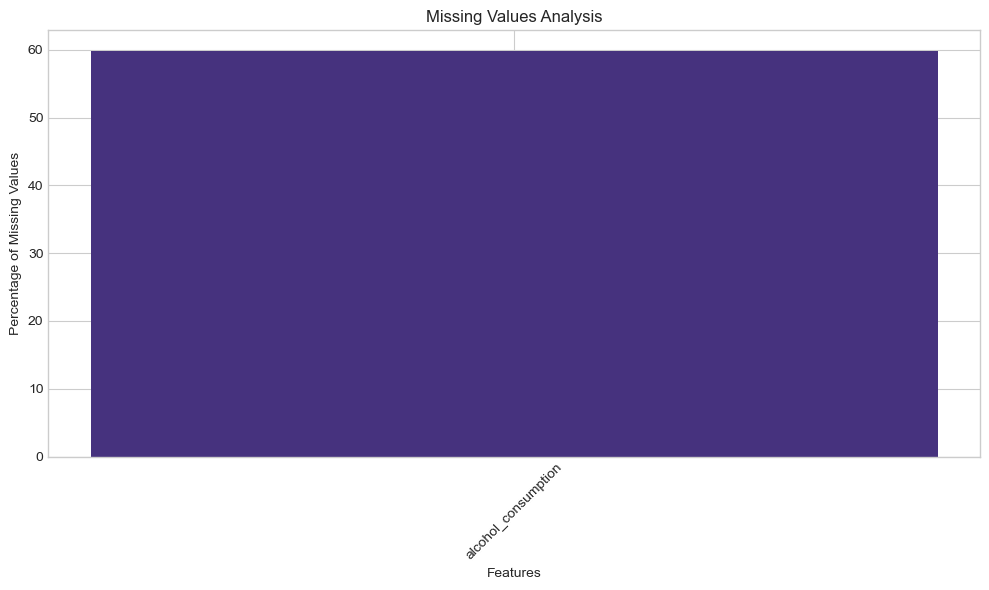

In [191]:
# Cell 3: Comprehensive check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Create a DataFrame for better visualization
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

# Sort by percentage of missing values
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print("Missing values per column:")
    print(missing_df)
    
    # Visualize missing values if any exist
    plt.figure(figsize=(10, 6))
    plt.bar(missing_df.index, missing_df['Percentage'])
    plt.xlabel('Features')
    plt.ylabel('Percentage of Missing Values')
    plt.title('Missing Values Analysis')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Check for patterns in missing values
    if len(missing_df) > 1:  # Only if multiple columns have missing values
        print("\nChecking for patterns in missing values...")
        import missingno as msno
        msno.matrix(df[missing_df.index])
        plt.title('Missing Values Pattern')
        plt.show()
else:
    print("No missing values found in the dataset.")

Data types:

Target variable distribution:
No heart attack (0): 94854 (59.90%)
Heart attack (1): 63501 (40.10%)


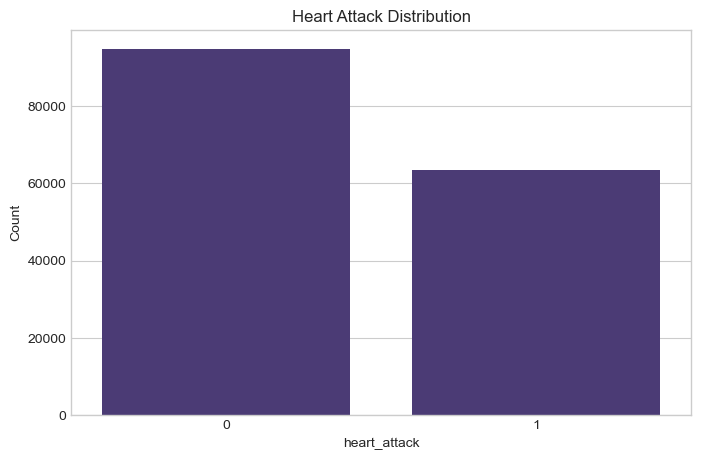

In [192]:
# Cell 4: Display data types and target variable distribution
print("Data types:")
df.dtypes

print("\nTarget variable distribution:")
heart_attack_counts = df['heart_attack'].value_counts()
print(f"No heart attack (0): {heart_attack_counts[0]} ({heart_attack_counts[0]/len(df):.2%})")
print(f"Heart attack (1): {heart_attack_counts[1]} ({heart_attack_counts[1]/len(df):.2%})")

# Visualize target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='heart_attack', data=df)
plt.title('Heart Attack Distribution')
plt.ylabel('Count')
plt.show()

In [193]:
# Cell 5: Explore basic statistics of numerical features
df.describe()

,age,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,sleep_hours,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
count,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000
mean,54.543778,0.299069,0.199804,199.533264,0.249901,93.268504,0.300218,6.480064,129.515772,79.490809,110.736762,49.491478,129.569916,149.715885,0.200575,0.499770,0.601029,0.401004
std,11.910897,0.457851,0.399854,39.737565,0.432957,16.382205,0.458354,1.425398,15.005641,10.002964,27.673445,9.982634,34.913318,49.023473,0.400432,0.500002,0.489688,0.490103
min,25.000000,0.000000,0.000000,100.000000,0.000000,20.000000,0.000000,3.000000,61.000000,37.000000,70.000000,8.000000,-19.000000,50.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,0.000000,172.000000,0.000000,82.000000,0.000000,5.492985,119.000000,73.000000,89.000000,43.000000,106.000000,116.000000,0.000000,0.000000,0.000000,0.000000
50%,55.000000,0.000000,0.000000,199.000000,0.000000,93.000000,0.000000,6.507461,130.000000,80.000000,109.000000,49.000000,130.000000,149.000000,0.000000,0.000000,1.000000,0.000000
75%,63.000000,1.000000,0.000000,226.000000,0.000000,104.000000,1.000000,7.520640,140.000000,86.000000,130.000000,56.000000,153.000000,183.000000,0.000000,1.000000,1.000000,1.000000
max,90.000000,1.000000,1.000000,350.000000,1.000000,173.000000,1.000000,9.000000,199.000000,127.000000,230.000000,93.000000,282.000000,380.000000,1.000000,1.000000,1.000000,1.000000


In [194]:
# Cell 6: Identify and organize column types
# Identify column types
categorical_columns = ['gender', 'region', 'income_level', 'smoking_status', 
                      'alcohol_consumption', 'physical_activity', 'dietary_habits',
                      'air_pollution_exposure', 'stress_level', 'EKG_results']

binary_columns = ['hypertension', 'diabetes', 'obesity', 'family_history', 
                 'previous_heart_disease', 'medication_usage', 'participated_in_free_screening']

numerical_columns = [col for col in df.columns if col not in categorical_columns + binary_columns + ['heart_attack']]

# Print column groups
print(f"Categorical columns: {categorical_columns}")
print(f"\nBinary columns: {binary_columns}")
print(f"\nNumerical columns: {numerical_columns}")

Categorical columns: ['gender', 'region', 'income_level', 'smoking_status', 'alcohol_consumption', 'physical_activity', 'dietary_habits', 'air_pollution_exposure', 'stress_level', 'EKG_results']

Binary columns: ['hypertension', 'diabetes', 'obesity', 'family_history', 'previous_heart_disease', 'medication_usage', 'participated_in_free_screening']

Numerical columns: ['age', 'cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']


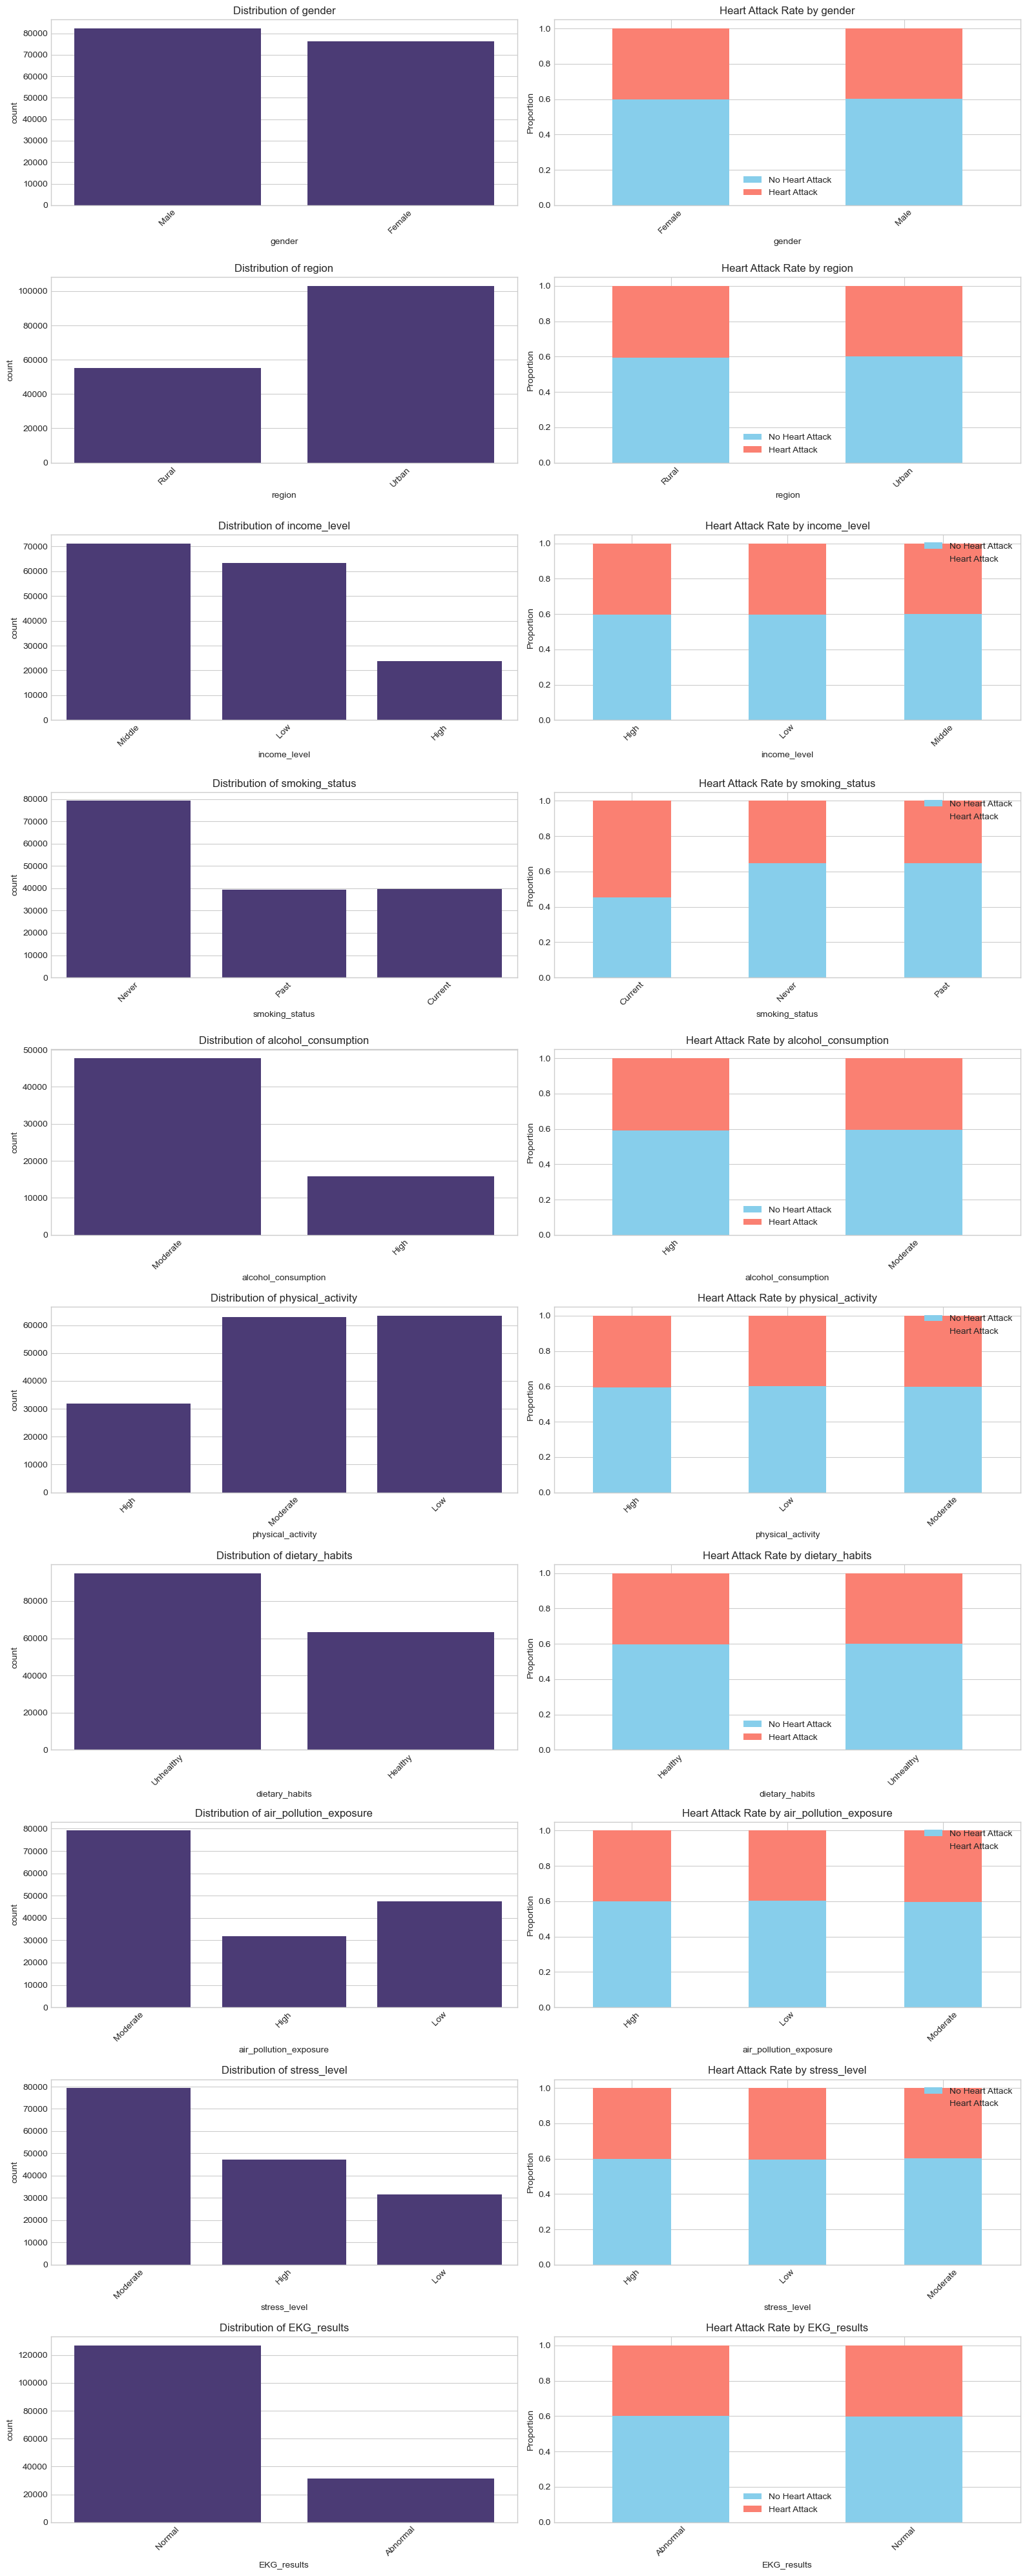

In [195]:
# Cell 7: Analyze categorical features
# Create a function to plot categorical features
def plot_categorical_features(df, columns, target='heart_attack'):
    num_cols = len(columns)
    fig, axes = plt.subplots(num_cols, 2, figsize=(16, 4 * num_cols))
    
    for i, col in enumerate(columns):
        # Count plot
        sns.countplot(x=col, data=df, ax=axes[i, 0])
        axes[i, 0].set_title(f'Distribution of {col}')
        axes[i, 0].tick_params(axis='x', rotation=45)
        
        # Stacked percentage by target
        pd.crosstab(df[col], df[target], normalize='index').plot(
            kind='bar', stacked=True, ax=axes[i, 1], 
            color=['skyblue', 'salmon']
        )
        axes[i, 1].set_title(f'Heart Attack Rate by {col}')
        axes[i, 1].set_ylabel('Proportion')
        axes[i, 1].legend(['No Heart Attack', 'Heart Attack'])
        axes[i, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Plot categorical features
plot_categorical_features(df, categorical_columns)

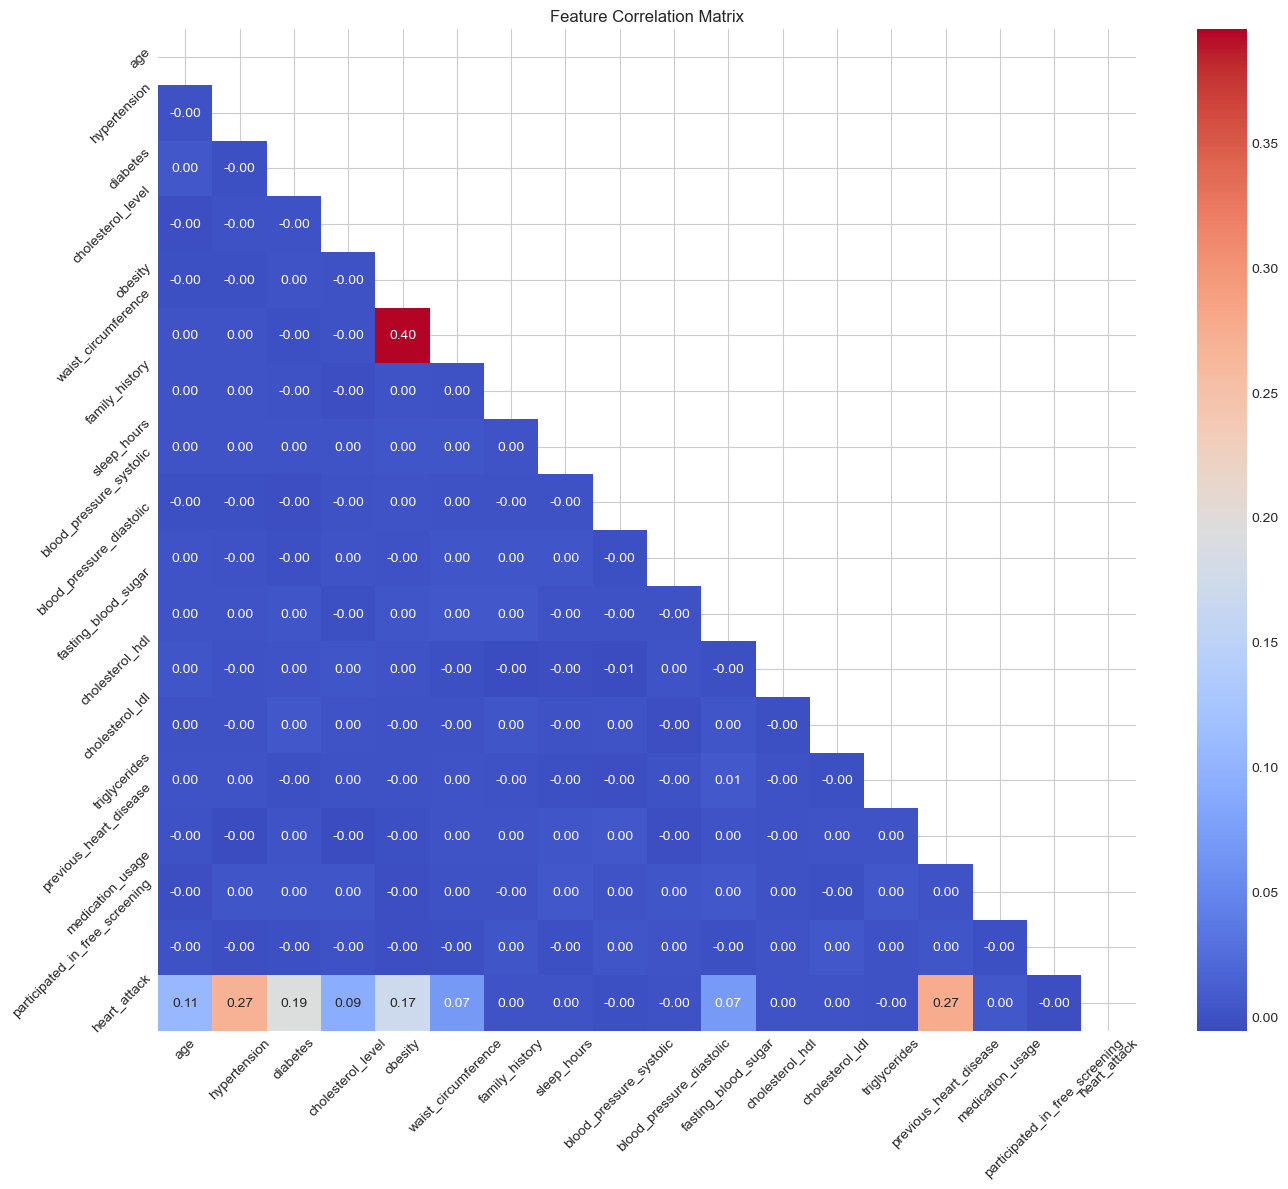

In [196]:
# Cell 8: Analyze numerical features
# Create correlation heatmap for numerical features only
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(14, 12))
corr_matrix = numeric_df.corr()
mask = np.triu(corr_matrix)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask)
plt.title('Feature Correlation Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

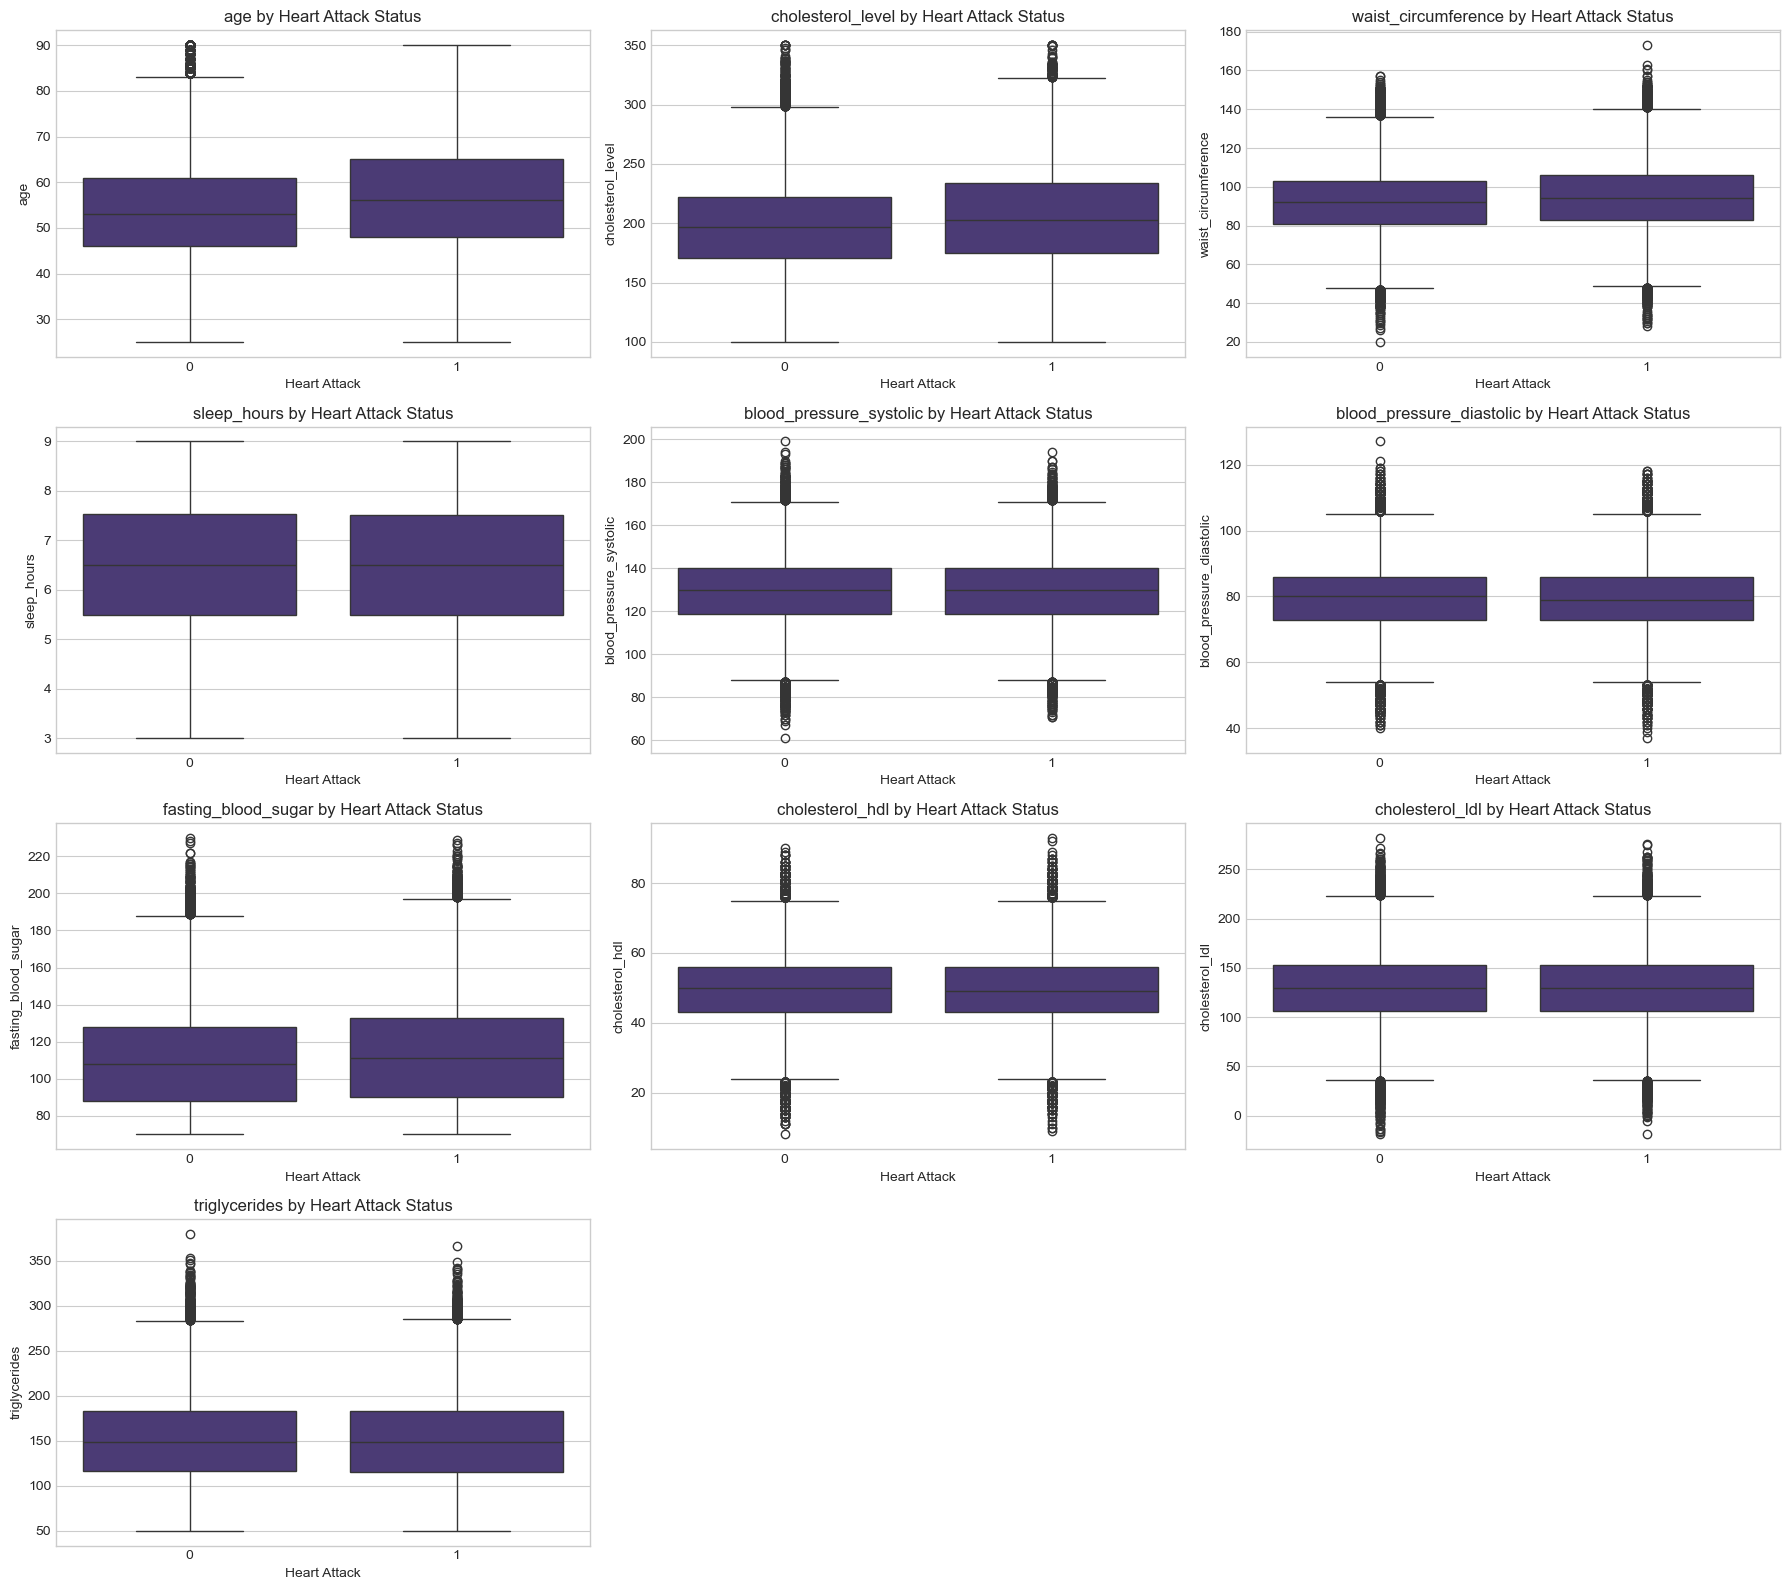

In [197]:
# Cell 9: Create boxplots for numerical features by heart attack status
def plot_boxplots(df, columns, target='heart_attack'):
    n_cols = 3
    n_rows = (len(columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        sns.boxplot(x=target, y=col, data=df, ax=axes[i])
        axes[i].set_title(f'{col} by Heart Attack Status')
        axes[i].set_xlabel('Heart Attack')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Plot boxplots
plot_boxplots(df, numerical_columns)

Chi-Square Test Results for Categorical Features:
Feature                   Chi2 Value      p-value         Significant
------------------------------------------------------------
gender                    1.9274          0.1650          No        
region                    4.9159          0.0266          Yes       
income_level              0.7773          0.6780          No        
smoking_status            4622.8357       0.0000          Yes       
alcohol_consumption       0.6659          0.4145          No        
physical_activity         3.7095          0.1565          No        
dietary_habits            4.3785          0.0364          Yes       
air_pollution_exposure    4.8183          0.0899          No        
stress_level              3.3326          0.1889          No        
EKG_results               1.0434          0.3070          No        


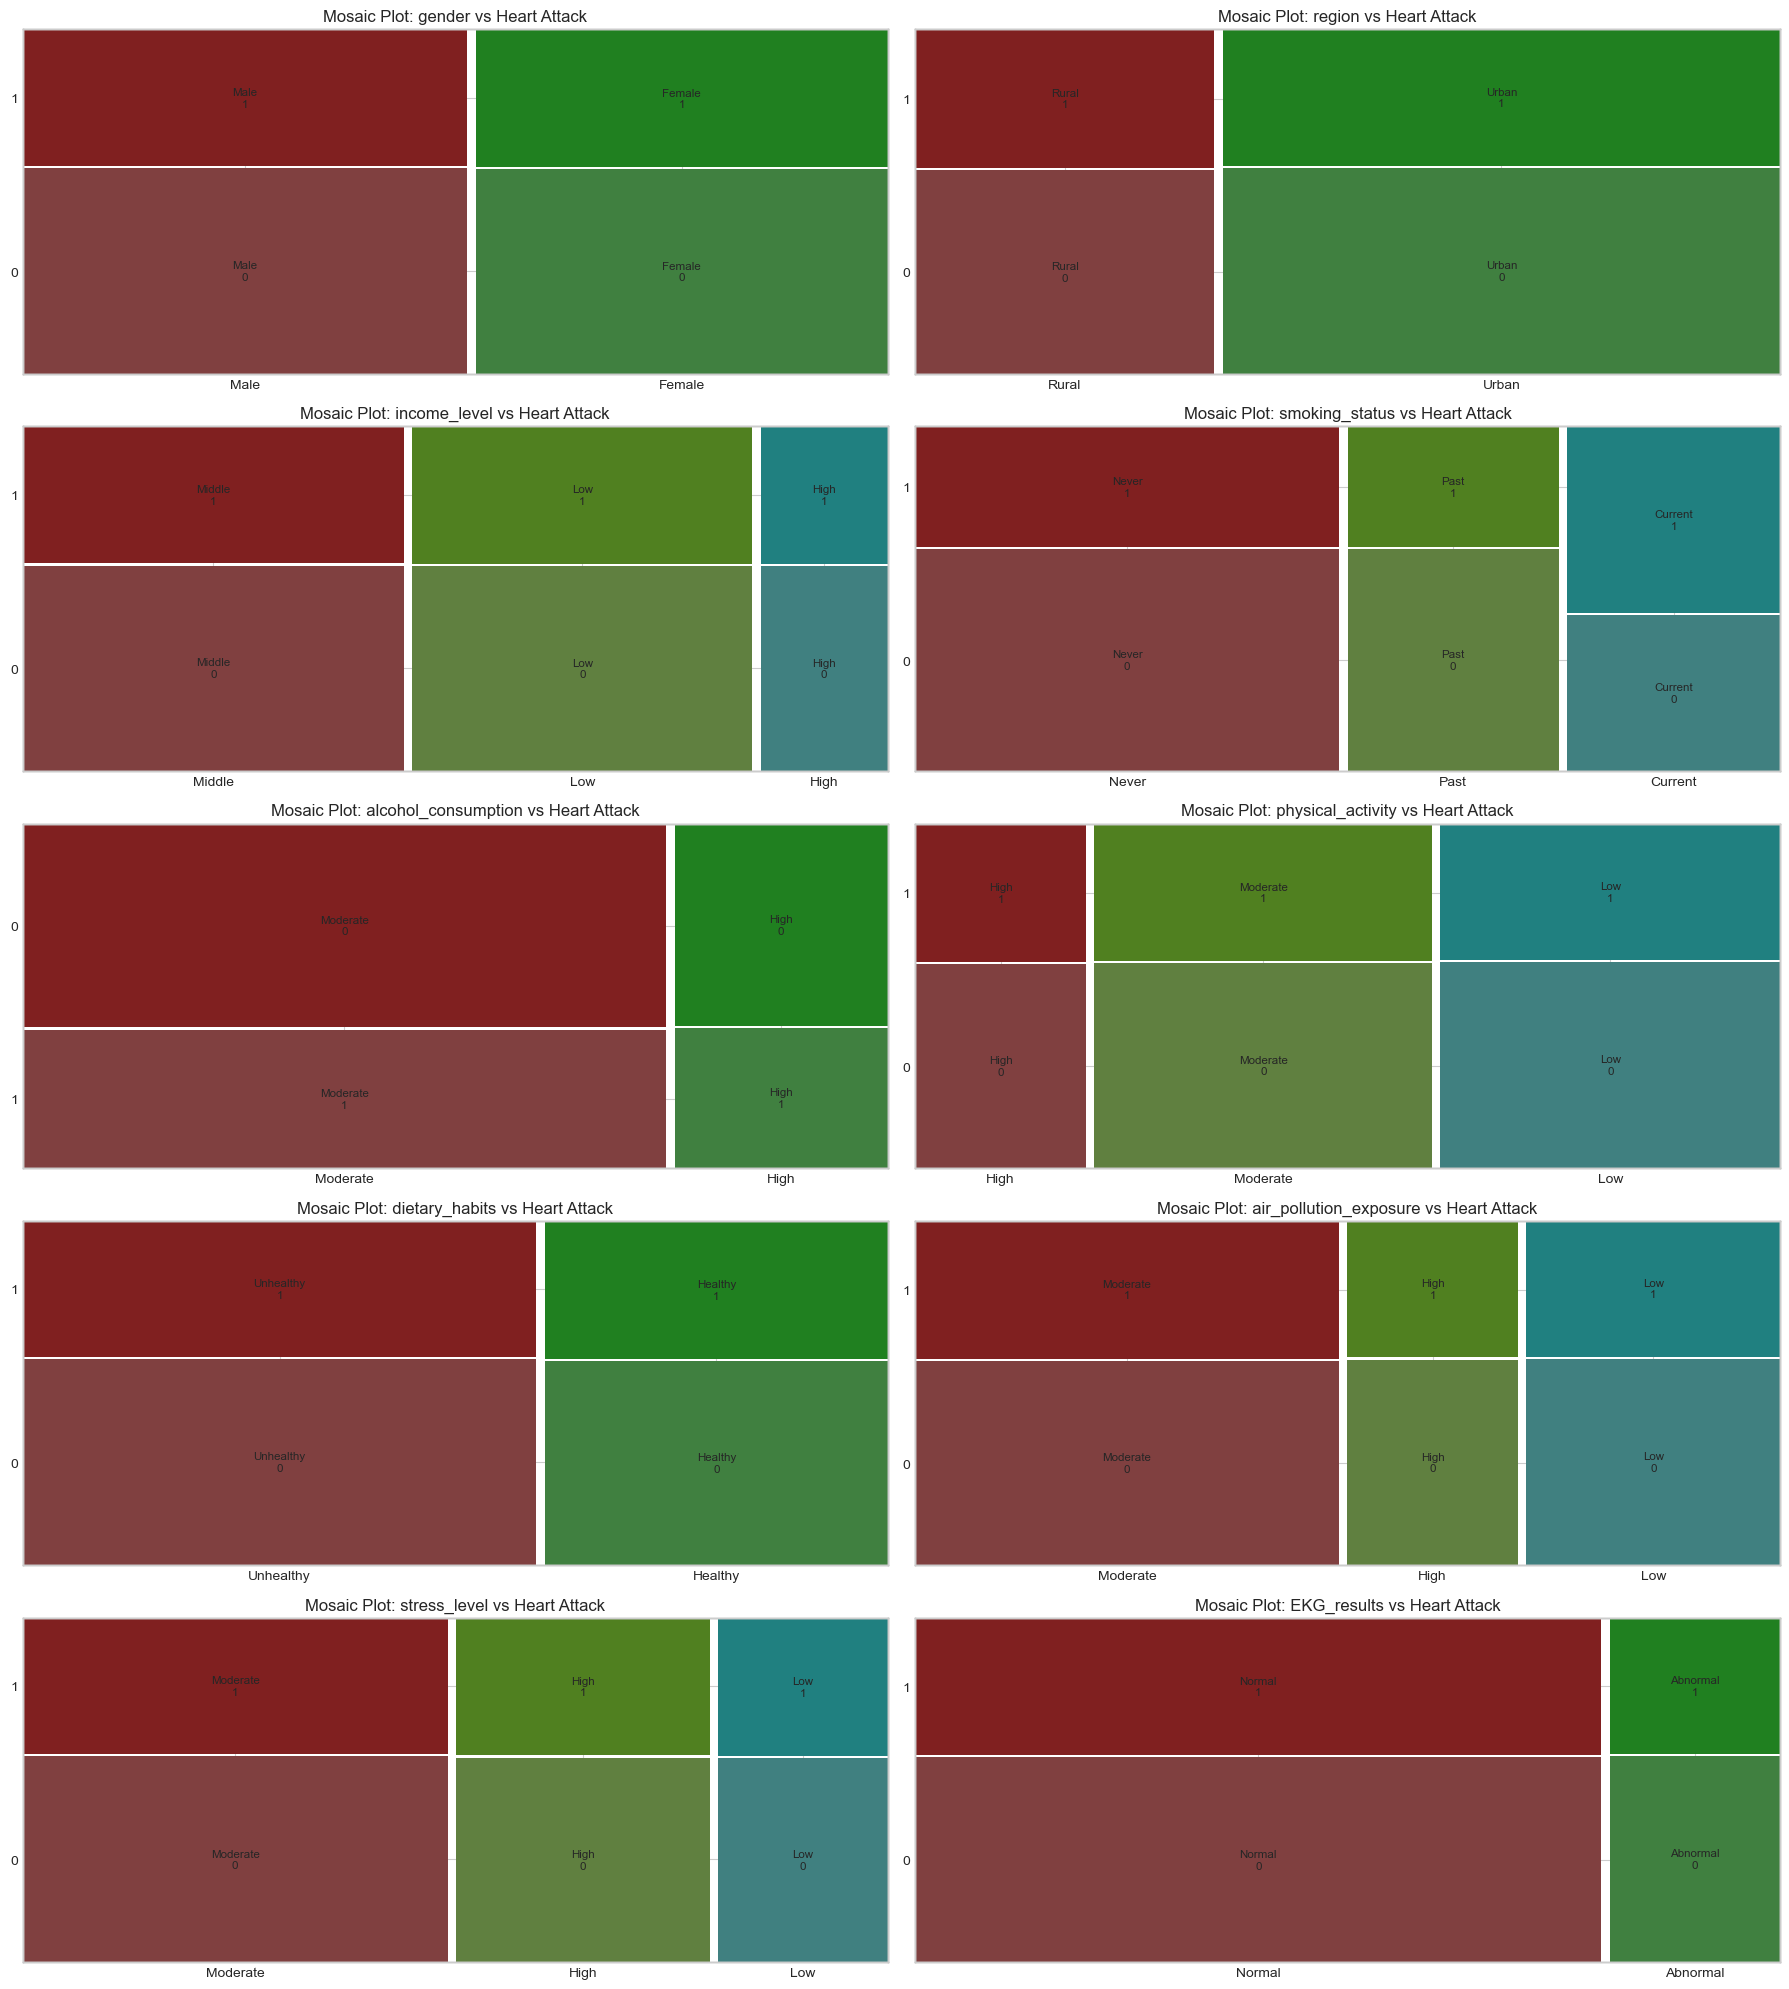

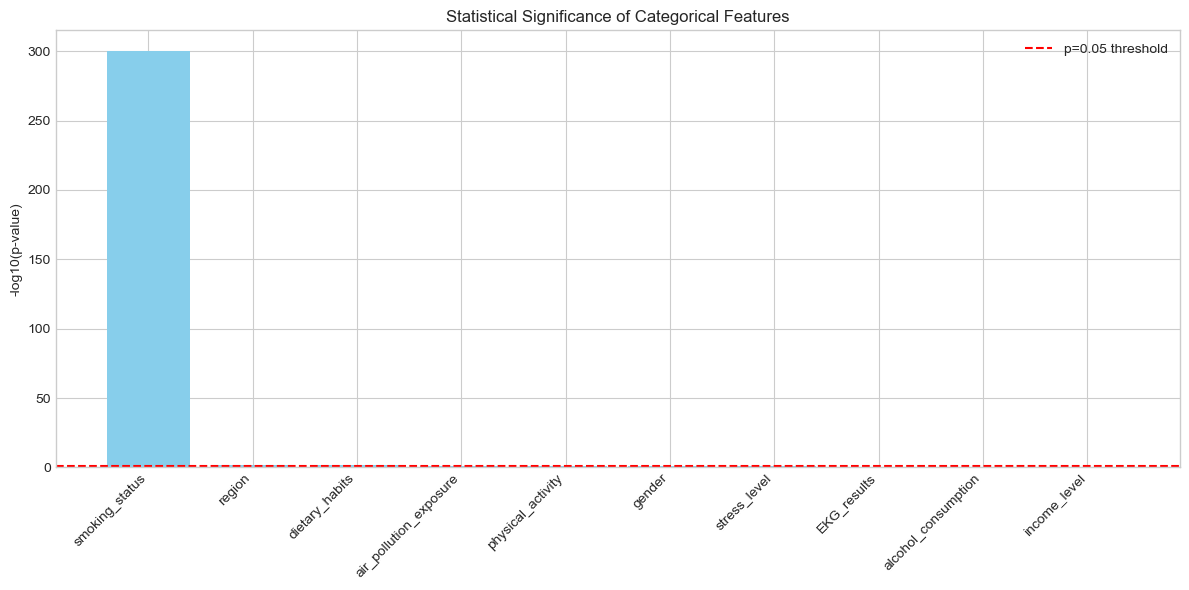

In [198]:
# Cell 9A: Add Chi-Square tests for categorical features
# This cell tests for statistically significant relationships between
# categorical variables and heart attack risk
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

# Function to perform chi-square test and create visualizations
def analyze_categorical_significance(df, categorical_cols, target='heart_attack'):
    # Store results
    results = []
    
    print("Chi-Square Test Results for Categorical Features:")
    print("=" * 60)
    print(f"{'Feature':<25} {'Chi2 Value':<15} {'p-value':<15} {'Significant':<10}")
    print("-" * 60)
    
    # Create figure for visualization
    n_cols = 2
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [axes]  # Make sure axes is always a list
    else:
        axes = axes.flatten()
    
    # Calculate chi-square and create mosaic plot for each categorical feature
    for i, col in enumerate(categorical_cols):
        # Create contingency table
        contingency = pd.crosstab(df[col], df[target])
        
        # Calculate chi-square
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        # Store results
        significant = "Yes" if p < 0.05 else "No"
        results.append({
            'Feature': col,
            'Chi2': chi2,
            'p-value': p,
            'Significant': significant
        })
        
        # Print results
        print(f"{col:<25} {chi2:<15.4f} {p:<15.4f} {significant:<10}")
        
        # Create mosaic plot
        from statsmodels.graphics.mosaicplot import mosaic
        
        # Create a crosstab dataframe
        cross_df = pd.crosstab(df[col], df[target]).rename(
            columns={0: 'No Heart Attack', 1: 'Heart Attack'})
        
        # Plot
        if i < len(axes):
            ax = axes[i]
            # Create a crosstab percentage
            props = {}
            for k in range(2):  # 0 and 1 for target
                for j, val in enumerate(contingency.index):
                    key = (val, k)
                    props[key] = {
                        'facecolor': 'lightblue' if k == 0 else 'salmon',
                        'alpha': 0.6 + 0.4 * (contingency.iloc[j, k] / contingency.values.sum()),
                        'edgecolor': 'black'
                    }
            
            mosaic(df, [col, target], ax=ax, properties=props, gap=0.01, 
                   title=f'Mosaic Plot: {col} vs Heart Attack')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Sort results by p-value
    results_df = pd.DataFrame(results).sort_values('p-value')
    
    # Create bar chart of p-values
    plt.figure(figsize=(12, 6))
    # Add a small epsilon to p-values to avoid log(0) errors
    epsilon = 1e-300  # Very small number
    log_p_values = -np.log10(results_df['p-value'] + epsilon)
    plt.bar(results_df['Feature'], log_p_values, color='skyblue')
    plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', label='p=0.05 threshold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('-log10(p-value)')
    plt.title('Statistical Significance of Categorical Features')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return results_df

# Run chi-square analysis on categorical features
categorical_significance = analyze_categorical_significance(df, categorical_columns)

Analyzing interactions for top categorical features: ['smoking_status', 'region', 'dietary_habits']

Interactions between smoking_status and numerical features:


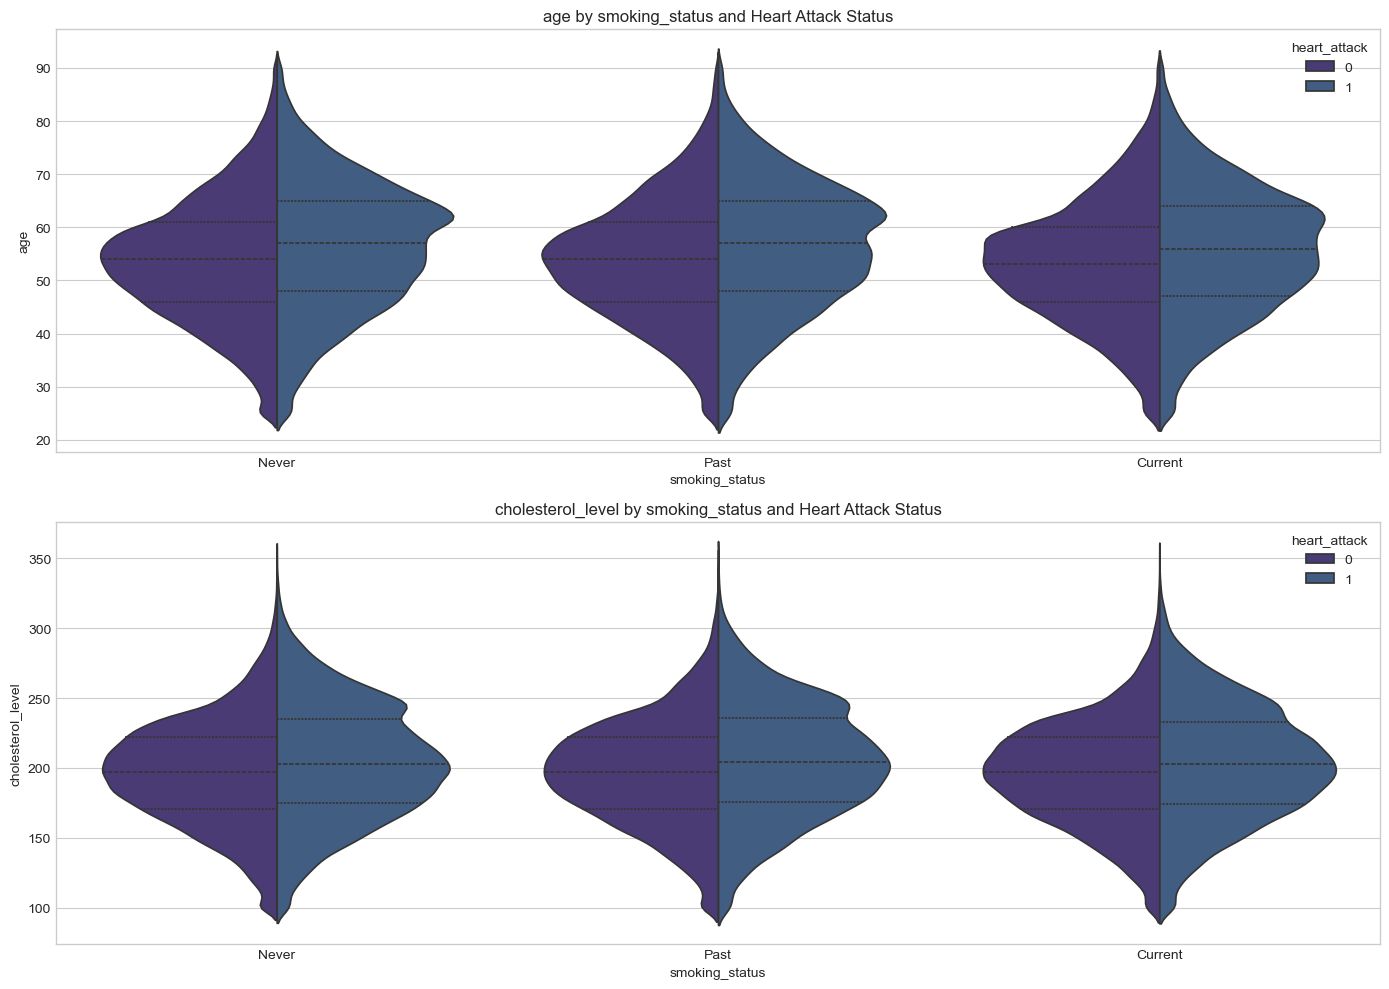


Interactions between region and numerical features:


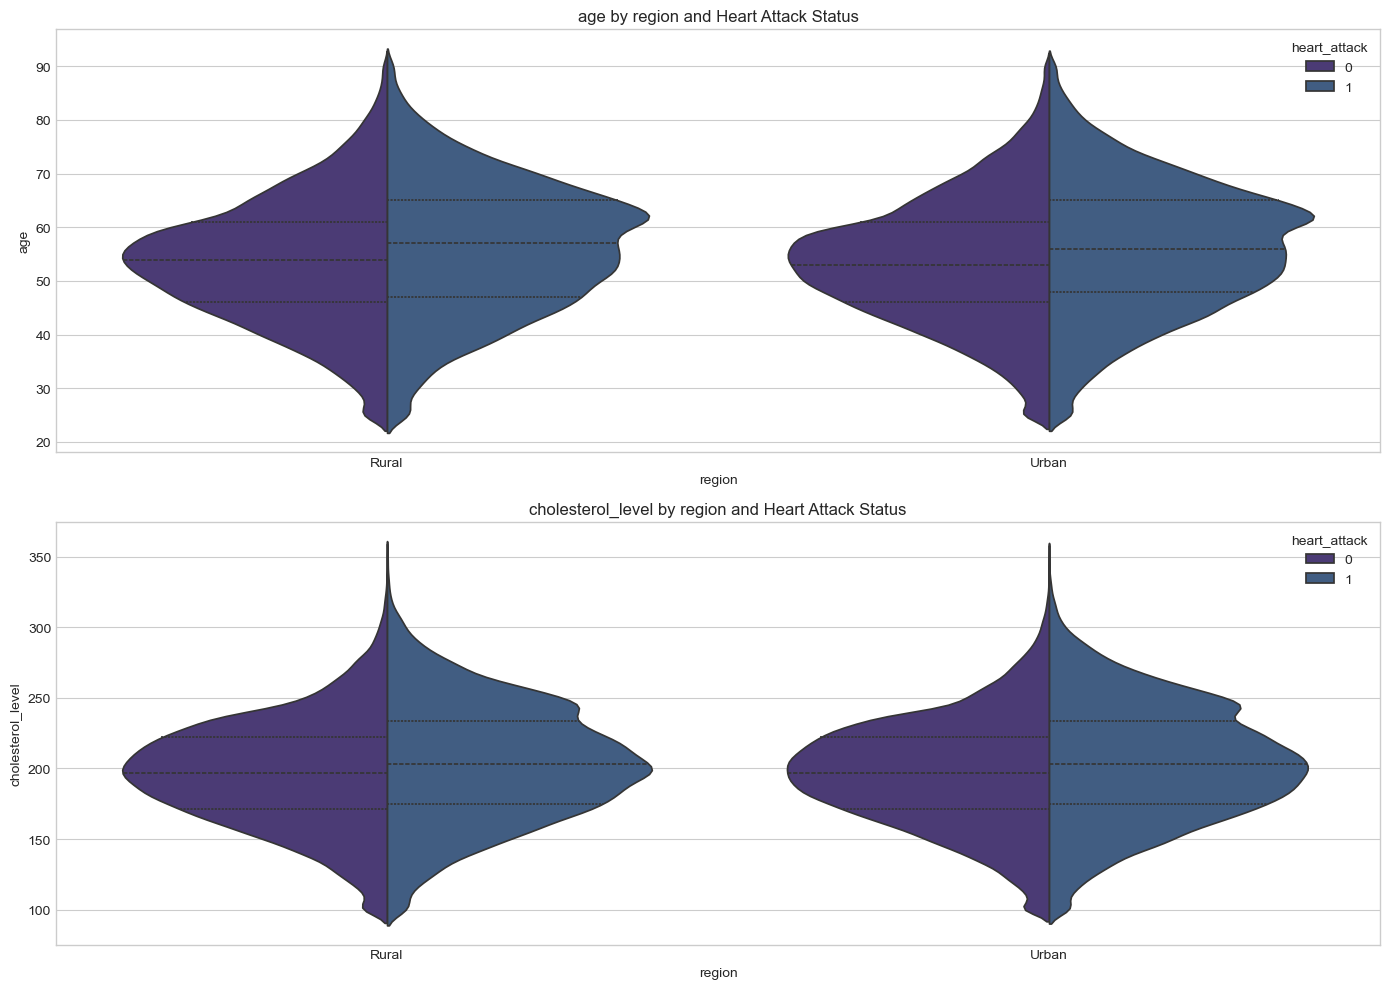


Interactions between dietary_habits and numerical features:


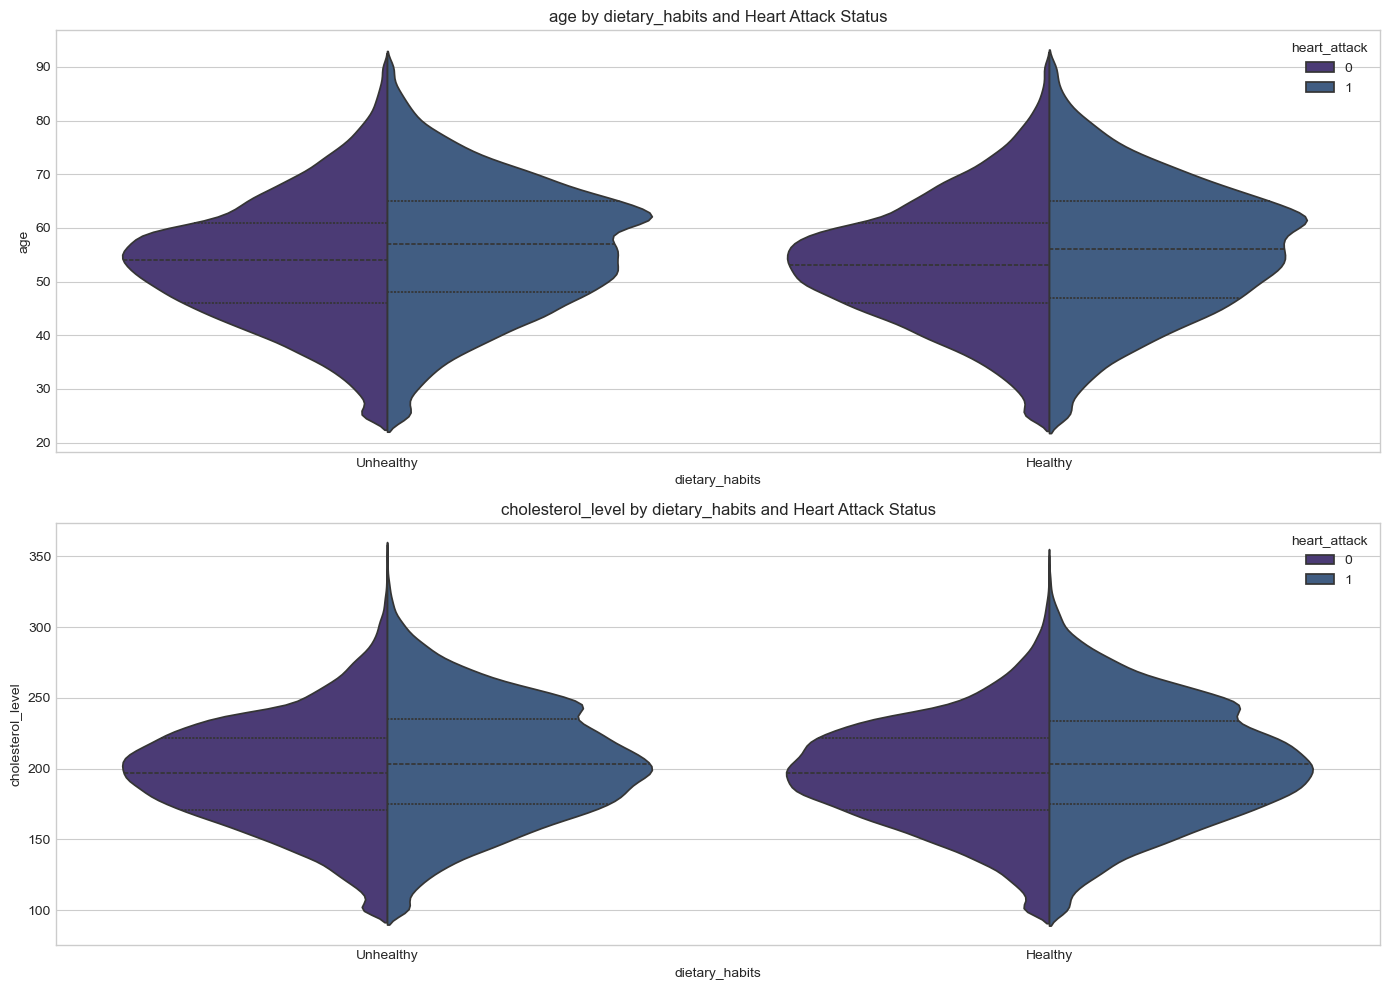

In [199]:
# Cell 9B: Analyze interaction between categorical and numerical features
# This cell creates violin plots to show how numerical features vary across 
# different categories, revealing potential interactions
def analyze_cat_num_interactions(df, cat_col, num_cols, target='heart_attack', top_n=3):
    # Verify cat_col is a categorical feature
    if cat_col not in df.columns or df[cat_col].dtype == 'float64':
        print(f"Error: {cat_col} is not a categorical feature in the dataset")
        return
    
    # Select the top numerical features based on categorical significance
    if len(num_cols) > top_n:
        # Filter to top n numerical features by correlation with target
        numeric_df = df[num_cols + [target]].select_dtypes(include=['number'])
        if numeric_df.shape[1] > 1:  # Ensure there are numerical features
            target_corr = numeric_df.corr()[target].abs().sort_values(ascending=False)
            top_num_features = target_corr[:top_n].index.tolist()
            top_num_features = [f for f in top_num_features if f != target]
        else:
            top_num_features = num_cols[:top_n]
    else:
        top_num_features = num_cols
    
    # Create plots
    fig, axes = plt.subplots(len(top_num_features), 1, figsize=(14, 5 * len(top_num_features)))
    if len(top_num_features) == 1:
        axes = [axes]
    
    # Plot violin plots for each numerical feature
    for i, num_col in enumerate(top_num_features):
        sns.violinplot(x=cat_col, y=num_col, hue=target, data=df, split=True, 
                     inner="quart", ax=axes[i])
        axes[i].set_title(f'{num_col} by {cat_col} and Heart Attack Status')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        if len(df[cat_col].unique()) > 4:  # If many categories, rotate labels
            axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Analyze top 3 categorical features based on chi-square results
top_categorical = categorical_significance.head(3)['Feature'].tolist()
print(f"Analyzing interactions for top categorical features: {top_categorical}")

for cat_feature in top_categorical:
    print(f"\nInteractions between {cat_feature} and numerical features:")
    analyze_cat_num_interactions(df, cat_feature, numerical_columns, top_n=3)

Age range in data: 25 to 90
Age group distribution:
age_group
25-35     8867
36-45    27056
46-55    48383
56-65    45516
66-75    22149
76+       6384
Name: count, dtype: int64

Systolic BP range: 61 to 199

BP category distribution:
bp_category
Normal      43317
Elevated    39765
Stage 1     38473
Stage 2     36740
Crisis         60
Name: count, dtype: int64


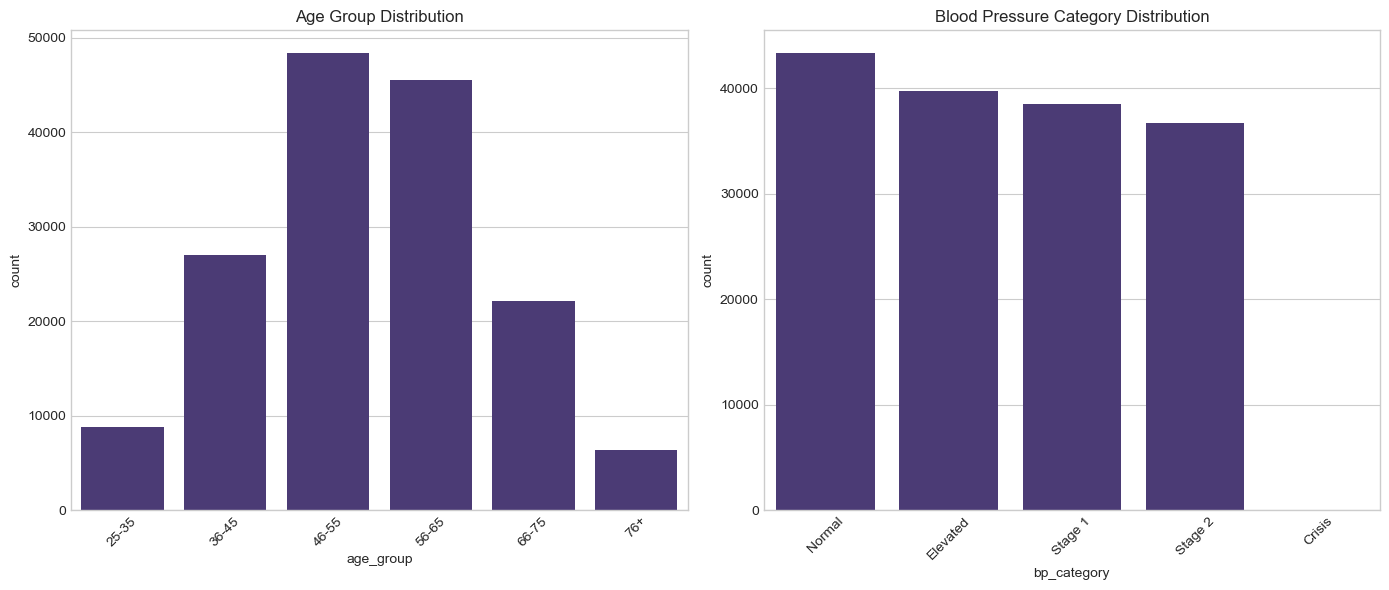


Chi-square test for age_group and heart attack:
Chi2 value: 2036.7966, p-value: 0.0000
The age_group feature shows significant association with heart attack risk

Chi-square test for bp_category and heart attack:
Chi2 value: 1.9155, p-value: 0.7513
The bp_category feature does not show significant association with heart attack risk


In [200]:
# Cell 10: Feature engineering with validation
# Create copy of dataframe to avoid modifying original
df_processed = df.copy()

# Add age groups with validation
age_min, age_max = df['age'].min(), df['age'].max()
print(f"Age range in data: {age_min} to {age_max}")

# Create age groups based on actual data distribution
age_bins = [age_min - 1, 35, 45, 55, 65, 75, age_max + 1]
age_labels = ['25-35', '36-45', '46-55', '56-65', '66-75', '76+']

df_processed['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Check distribution of new feature
age_group_counts = df_processed['age_group'].value_counts().sort_index()
print("Age group distribution:")
print(age_group_counts)

# Blood pressure categories with validation
bp_systolic_min, bp_systolic_max = df['blood_pressure_systolic'].min(), df['blood_pressure_systolic'].max()
print(f"\nSystolic BP range: {bp_systolic_min} to {bp_systolic_max}")

# Create BP categories according to clinical guidelines
bp_bins = [0, 120, 130, 140, 180, bp_systolic_max + 1]
bp_labels = ['Normal', 'Elevated', 'Stage 1', 'Stage 2', 'Crisis']

df_processed['bp_category'] = pd.cut(df['blood_pressure_systolic'], bins=bp_bins, labels=bp_labels)

# Check distribution of new feature
bp_category_counts = df_processed['bp_category'].value_counts().sort_index()
print("\nBP category distribution:")
print(bp_category_counts)

# Plot distribution of these new features
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Age group plot
sns.countplot(x='age_group', data=df_processed, ax=axes[0])
axes[0].set_title('Age Group Distribution')
axes[0].tick_params(axis='x', rotation=45)

# BP category plot
sns.countplot(x='bp_category', data=df_processed, ax=axes[1])
axes[1].set_title('Blood Pressure Category Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Test association with target variable
from scipy.stats import chi2_contingency

for feature in ['age_group', 'bp_category']:
    contingency = pd.crosstab(df_processed[feature], df_processed['heart_attack'])
    chi2, p, _, _ = chi2_contingency(contingency)
    print(f"\nChi-square test for {feature} and heart attack:")
    print(f"Chi2 value: {chi2:.4f}, p-value: {p:.4f}")
    
    if p < 0.05:
        print(f"The {feature} feature shows significant association with heart attack risk")
        # Keep this feature for modeling
    else:
        print(f"The {feature} feature does not show significant association with heart attack risk")
        # Consider removing this feature

In [202]:
# Cell 10A: Clinically relevant feature engineering based on variable definitions
print("Creating clinically relevant features...")

# Create a copy of the dataframe for feature engineering
df_clinical = df.copy()

# 1. BMI categories based on waist_circumference and obesity
if 'waist_circumference' in df.columns and 'obesity' in df.columns:
    # Create metabolic risk categories based on waist circumference
    # Using clinical guidelines for abdominal obesity
    def get_metabolic_risk(row):
        if row['gender'] == 'Male':
            if row['waist_circumference'] >= 102:  # cm
                return 'High'
            elif row['waist_circumference'] >= 94:
                return 'Increased'
            else:
                return 'Normal'
        else:  # Female
            if row['waist_circumference'] >= 88:  # cm
                return 'High'
            elif row['waist_circumference'] >= 80:
                return 'Increased'
            else:
                return 'Normal'
    
    df_clinical['metabolic_risk'] = df.apply(get_metabolic_risk, axis=1)
    print("Created 'metabolic_risk' feature based on gender and waist circumference")

# 2. Cholesterol risk categories based on clinical guidelines
if all(col in df.columns for col in ['cholesterol_level', 'cholesterol_hdl', 'cholesterol_ldl']):
    # Total Cholesterol categories
    df_clinical['cholesterol_category'] = pd.cut(
        df['cholesterol_level'],
        bins=[0, 200, 240, 1000],
        labels=['Desirable', 'Borderline', 'High']
    )
    
    # HDL categories (higher is better)
    df_clinical['hdl_category'] = pd.cut(
        df['cholesterol_hdl'],
        bins=[0, 40, 60, 100],
        labels=['Low', 'Moderate', 'Optimal']
    )
    
    # LDL categories
    df_clinical['ldl_category'] = pd.cut(
        df['cholesterol_ldl'],
        bins=[0, 100, 130, 160, 1000],
        labels=['Optimal', 'Near Optimal', 'Borderline', 'High']
    )
    
    print("Created cholesterol category features based on clinical guidelines")

# 3. Blood pressure categories per JNC 8 guidelines
if 'blood_pressure_systolic' in df.columns and 'blood_pressure_diastolic' in df.columns:
    # Function to categorize BP according to JNC 8
    def bp_category(row):
        systolic = row['blood_pressure_systolic']
        diastolic = row['blood_pressure_diastolic']
        
        if systolic < 120 and diastolic < 80:
            return 'Normal'
        elif (120 <= systolic < 130) and diastolic < 80:
            return 'Elevated'
        elif (130 <= systolic < 140) or (80 <= diastolic < 90):
            return 'Stage 1'
        elif (systolic >= 140) or (diastolic >= 90):
            return 'Stage 2'
        elif systolic >= 180 or diastolic >= 120:
            return 'Crisis'
        else:
            return 'Unknown'
    
    df_clinical['bp_jnc8_category'] = df.apply(bp_category, axis=1)
    print("Created 'bp_jnc8_category' feature using both systolic and diastolic values")

# 4. Diabetes risk based on fasting blood sugar
if 'fasting_blood_sugar' in df.columns:
    df_clinical['glucose_category'] = pd.cut(
        df['fasting_blood_sugar'],
        bins=[0, 100, 126, 1000],
        labels=['Normal', 'Prediabetes', 'Diabetes']
    )
    print("Created 'glucose_category' feature based on fasting blood sugar")

# 5. Combined lifestyle risk score
lifestyle_vars = ['smoking_status', 'alcohol_consumption', 'physical_activity', 'dietary_habits']
if all(var in df.columns for var in lifestyle_vars):
    # Create scores for each lifestyle factor
    lifestyle_scores = {
        'smoking_status': {'Never': 0, 'Past': 1, 'Current': 2},
        'alcohol_consumption': {'None': 0, 'Moderate': 1, 'High': 2},
        'physical_activity': {'High': 0, 'Moderate': 1, 'Low': 2},
        'dietary_habits': {'Healthy': 0, 'Unhealthy': 2}
    }
    
    # Calculate combined score
    df_clinical['lifestyle_risk_score'] = 0
    for var, scores in lifestyle_scores.items():
        df_clinical['lifestyle_risk_score'] += df_clinical[var].map(scores).fillna(0)
    
    # Create category from score
    max_score = sum(max(scores.values()) for scores in lifestyle_scores.values())
    df_clinical['lifestyle_risk'] = pd.cut(
        df_clinical['lifestyle_risk_score'],
        bins=[-1, max_score/3, 2*max_score/3, max_score+1],
        labels=['Low', 'Moderate', 'High']
    )
    print(f"Created 'lifestyle_risk' feature (score range: 0-{max_score})")

# 6. Comorbidity count (multiple conditions)
comorbidity_vars = ['hypertension', 'diabetes', 'obesity', 'previous_heart_disease']
if all(var in df.columns for var in comorbidity_vars):
    df_clinical['comorbidity_count'] = df[comorbidity_vars].sum(axis=1)
    
    # Create categories
    df_clinical['comorbidity_level'] = pd.cut(
        df_clinical['comorbidity_count'],
        bins=[-1, 0, 1, len(comorbidity_vars)],
        labels=['None', 'Single', 'Multiple']
    )
    print("Created 'comorbidity_count' and 'comorbidity_level' features")

# Display the distribution of new features
new_features = [col for col in df_clinical.columns if col not in df.columns]
if new_features:
    print(f"\nCreated {len(new_features)} new features:")
    for feature in new_features:
        print(f"- {feature}: {df_clinical[feature].value_counts().to_dict()}")
else:
    print("No new features were created - check if required columns are present in dataset")

# Check association with target
for feature in new_features:
    try:
        if df_clinical[feature].dtype.name in ['category', 'object']:
            # Chi-square for categorical features
            from scipy.stats import chi2_contingency
            contingency = pd.crosstab(df_clinical[feature], df_clinical['heart_attack'])
            chi2, p, _, _ = chi2_contingency(contingency)
            print(f"{feature}: chi2={chi2:.2f}, p-value={p:.4f} {'(significant)' if p < 0.05 else ''}")
        else:
            # T-test for numerical features
            from scipy.stats import ttest_ind
            t, p = ttest_ind(
                df_clinical.loc[df_clinical['heart_attack']==1, feature].dropna(),
                df_clinical.loc[df_clinical['heart_attack']==0, feature].dropna()
            )
            print(f"{feature}: t={t:.2f}, p-value={p:.4f} {'(significant)' if p < 0.05 else ''}")
    except Exception as e:
        print(f"Could not test {feature}: {e}")

# Save the enhanced dataset for future use
df_processed = df_clinical.copy()

Creating clinically relevant features...
Created 'metabolic_risk' feature based on gender and waist circumference
Created cholesterol category features based on clinical guidelines
Created 'bp_jnc8_category' feature using both systolic and diastolic values
Created 'glucose_category' feature based on fasting blood sugar
Created 'lifestyle_risk' feature (score range: 0-8)
Created 'comorbidity_count' and 'comorbidity_level' features

Created 10 new features:
- metabolic_risk: {'High': 73250, 'Normal': 57189, 'Increased': 27916}
- cholesterol_category: {'Desirable': 80876, 'Borderline': 53417, 'High': 24062}
- hdl_category: {'Moderate': 107870, 'Low': 28988, 'Optimal': 21497}
- ldl_category: {'Near Optimal': 48845, 'Borderline': 47632, 'Optimal': 32052, 'High': 29806}
- bp_jnc8_category: {'Stage 1': 80144, 'Stage 2': 38839, 'Normal': 19710, 'Elevated': 19662}
- glucose_category: {'Normal': 60815, 'Prediabetes': 52535, 'Diabetes': 45005}
- lifestyle_risk_score: {4.0: 37702, 3.0: 32886, 5.0:

In [203]:
# Cell 11: Use engineered features appropriately based on statistical significance
# Based on the statistical tests in Cell 10, decide which features to keep

# Assume both new features showed significant association (modify based on actual results)
# If both features are significant, add them to categorical_columns
if 'age_group' in df_processed.columns and 'bp_category' in df_processed.columns:
    print("Adding engineered features to categorical columns")
    categorical_columns.extend(['age_group', 'bp_category'])

# Create updated feature lists
print(f"Original categorical columns: {categorical_columns}")

# Separate features and target
X = df_processed.drop(['heart_attack'], axis=1)  # Keep all engineered features that are significant
y = df_processed['heart_attack']

# Create preprocessing transformers
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Create updated list of numerical columns (excluding any engineered categorical features)
numerical_columns = [col for col in X.columns if col not in categorical_columns + binary_columns]

print(f"Updated numerical columns: {numerical_columns}")

# Combine transformers into preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns),
        ('bin', binary_transformer, binary_columns)
    ],
    remainder='drop'  # This will drop columns that aren't specified
)

print(f"Preprocessing pipeline created with {len(numerical_columns)} numerical features, " 
      f"{len(categorical_columns)} categorical features, and {len(binary_columns)} binary features")

Original categorical columns: ['gender', 'region', 'income_level', 'smoking_status', 'alcohol_consumption', 'physical_activity', 'dietary_habits', 'air_pollution_exposure', 'stress_level', 'EKG_results']
Updated numerical columns: ['age', 'cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides', 'metabolic_risk', 'cholesterol_category', 'hdl_category', 'ldl_category', 'bp_jnc8_category', 'glucose_category', 'lifestyle_risk_score', 'lifestyle_risk', 'comorbidity_count', 'comorbidity_level']
Preprocessing pipeline created with 20 numerical features, 10 categorical features, and 7 binary features


In [204]:
# Cell 12: Split the data into train and test sets
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (126684, 37)
Testing set shape: (31671, 37)


In [206]:
# Cell 13: Apply preprocessing pipeline with proper feature type categorization
# First, check the data types to ensure proper preprocessing

# Make sure we're using the dataframe with engineered features if it exists
if 'df_clinical' in locals() or 'df_clinical' in globals():
    X = df_clinical.drop('heart_attack', axis=1)
    y = df_clinical['heart_attack']
    print("Using enhanced dataframe with clinical features")
else:
    X = X  # Use the original X if df_clinical doesn't exist
    y = y  # Use the original y
    print("Using original dataframe (no clinical features found)")

# Reset our feature category lists to include new engineered features
print("\nRe-categorizing features to include engineered features...")

# Find all categorical features based on dtype
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Detected {len(categorical_cols)} categorical features based on data type")

# Find all binary features (those with only 0 and 1 values)
binary_cols = []
for col in X.select_dtypes(include=['int', 'float']).columns:
    unique_vals = X[col].dropna().unique()
    if set(unique_vals).issubset({0, 1}) and len(unique_vals) <= 2:
        binary_cols.append(col)
print(f"Detected {len(binary_cols)} binary features")

# All remaining numeric features
numerical_cols = [col for col in X.columns 
                  if col not in categorical_cols and col not in binary_cols]
print(f"Detected {len(numerical_cols)} numerical features")

# Create preprocessor with appropriate transformers
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine transformers into preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('bin', binary_transformer, binary_cols)
    ])

print("\nFeature categories for preprocessing:")
print(f"Categorical features: {categorical_cols}")
print(f"Binary features: {binary_cols}")
print(f"Numerical features: {numerical_cols[:5]}... (total: {len(numerical_cols)})")

# Split the data into train and test sets if not already done
if 'X_train' not in locals() or 'X_test' not in locals():
    print("\nSplitting data into train and test sets...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")

# Apply preprocessing pipeline
try:
    print("\nApplying preprocessing pipeline...")
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    X_test_preprocessed = preprocessor.transform(X_test)
    
    print(f"Preprocessed training set shape: {X_train_preprocessed.shape}")
    print(f"Preprocessed testing set shape: {X_test_preprocessed.shape}")
    
    # Get feature names after preprocessing for later use
    feature_names = []
    
    # Add numerical feature names
    feature_names.extend(numerical_cols)
    
    # Add one-hot encoded categorical feature names
    for i, col in enumerate(categorical_cols):
        try:
            # Get the categories from the OneHotEncoder
            categories = preprocessor.transformers_[1][1].named_steps['onehot'].categories_[i]
            for category in categories:
                feature_names.append(f"{col}_{category}")
        except:
            # If we can't get categories, use a generic name
            feature_names.append(f"categorical_{col}")
    
    # Add binary feature names
    feature_names.extend(binary_cols)
    
    print(f"Total features after preprocessing: {len(feature_names)}")
    
except Exception as e:
    print(f"Error during preprocessing: {str(e)}")
    
    # Debug information
    print("\nDebugging information:")
    for col in X_train.columns:
        print(f"Column '{col}': dtype={X_train[col].dtype}, unique_values={X_train[col].nunique()}")
        if X_train[col].dtype == 'object':
            print(f"  Sample values: {X_train[col].value_counts().head(3).to_dict()}")

Using enhanced dataframe with clinical features

Re-categorizing features to include engineered features...
Detected 18 categorical features based on data type
Detected 7 binary features
Detected 12 numerical features

Feature categories for preprocessing:
Categorical features: ['gender', 'region', 'income_level', 'smoking_status', 'alcohol_consumption', 'physical_activity', 'dietary_habits', 'air_pollution_exposure', 'stress_level', 'EKG_results', 'metabolic_risk', 'cholesterol_category', 'hdl_category', 'ldl_category', 'bp_jnc8_category', 'glucose_category', 'lifestyle_risk', 'comorbidity_level']
Binary features: ['hypertension', 'diabetes', 'obesity', 'family_history', 'previous_heart_disease', 'medication_usage', 'participated_in_free_screening']
Numerical features: ['age', 'cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic']... (total: 12)

Applying preprocessing pipeline...
Preprocessed training set shape: (126684, 70)
Preprocessed testing set sha

In [207]:
# Cell 14: Get feature names after preprocessing
# Get feature names for numerical and binary columns
feature_names = list(numerical_columns)

# For categorical columns with one-hot encoding, get the new feature names
cat_features = []
for i, col in enumerate(categorical_columns):
    # Access the categories only if we have categorical columns
    if len(categorical_columns) > 0:
        onehot_categories = preprocessor.transformers_[1][1].named_steps['onehot'].categories_[i]
        for cat in onehot_categories:
            cat_features.append(f"{col}_{cat}")

feature_names.extend(cat_features)
feature_names.extend(binary_columns)

print(f"Number of features after preprocessing: {len(feature_names)}")
print("First 10 feature names:")
print(feature_names[:10])

Number of features after preprocessing: 52
First 10 feature names:
['age', 'cholesterol_level', 'waist_circumference', 'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl', 'triglycerides']


In [208]:
# Cell 15: Better approach to handle class imbalance
# Calculate class distribution
class_counts = y_train.value_counts()
minority_class_ratio = class_counts.min() / class_counts.max()
print(f"Class distribution: {dict(class_counts)}")
print(f"Minority to majority class ratio: {minority_class_ratio:.3f}")

# Determine appropriate imbalance handling strategy based on data
if minority_class_ratio < 0.2:
    print("Severe class imbalance detected (ratio < 0.2)")
    print("Applying SMOTE with BorderlineSMOTE for better quality synthetic samples...")
    
    # Try BorderlineSMOTE which often works better than regular SMOTE
    from imblearn.over_sampling import BorderlineSMOTE
    
    # Use cross-validation to determine optimal sampling strategy
    sampling_strategies = [0.5, 0.75, 1.0]  # Different levels of oversampling
    best_f1 = 0
    best_strategy = None
    
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import f1_score
    from sklearn.ensemble import RandomForestClassifier
    
    # Simple model for strategy evaluation
    base_model = RandomForestClassifier(n_estimators=50, random_state=random_state)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
    
    for strategy in sampling_strategies:
        f1_scores = []
        
        for train_idx, val_idx in skf.split(X_train_preprocessed, y_train):
            X_train_fold, X_val_fold = X_train_preprocessed[train_idx], X_train_preprocessed[val_idx]
            y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            # Apply oversampling
            smote = BorderlineSMOTE(sampling_strategy=strategy, random_state=random_state)
            X_res, y_res = smote.fit_resample(X_train_fold, y_train_fold)
            
            # Train and evaluate
            base_model.fit(X_res, y_res)
            y_pred = base_model.predict(X_val_fold)
            f1 = f1_score(y_val_fold, y_pred)
            f1_scores.append(f1)
        
        avg_f1 = sum(f1_scores) / len(f1_scores)
        print(f"Strategy {strategy}: Average F1 = {avg_f1:.4f}")
        
        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_strategy = strategy
    
    print(f"Best sampling strategy: {best_strategy} (F1 = {best_f1:.4f})")
    
    # Apply the best strategy to the full training set
    smote = BorderlineSMOTE(sampling_strategy=best_strategy, random_state=random_state)
    X_train_preprocessed, y_train = smote.fit_resample(X_train_preprocessed, y_train)
    
    # Check new class distribution
    new_class_counts = pd.Series(y_train).value_counts()
    print("New class distribution after SMOTE:")
    for val, count in zip(new_class_counts.index, new_class_counts.values):
        print(f"Class {val}: {count} ({count/len(y_train):.2%})")
elif minority_class_ratio < 0.4:
    print("Moderate class imbalance detected (ratio between 0.2 and 0.4)")
    print("Applying regular SMOTE...")
    
    # Standard SMOTE
    smote = SMOTE(random_state=random_state)
    X_train_preprocessed, y_train = smote.fit_resample(X_train_preprocessed, y_train)
    
    # Check new class distribution
    new_class_counts = pd.Series(y_train).value_counts()
    print("New class distribution after SMOTE:")
    for val, count in zip(new_class_counts.index, new_class_counts.values):
        print(f"Class {val}: {count} ({count/len(y_train):.2%})")
else:
    print("Mild or no class imbalance detected (ratio >= 0.4)")
    print("Using class weights instead of oversampling to preserve data distribution...")
    
    # Calculate class weights for use in model training
    class_weights = {0: 1, 1: class_counts[0] / class_counts[1]}
    print(f"Class weights: {class_weights}")
    print("These weights will be passed to the model in the training phase")

Class distribution: {0: 75883, 1: 50801}
Minority to majority class ratio: 0.669
Mild or no class imbalance detected (ratio >= 0.4)
Using class weights instead of oversampling to preserve data distribution...
Class weights: {0: 1, 1: 1.4937304383771972}
These weights will be passed to the model in the training phase


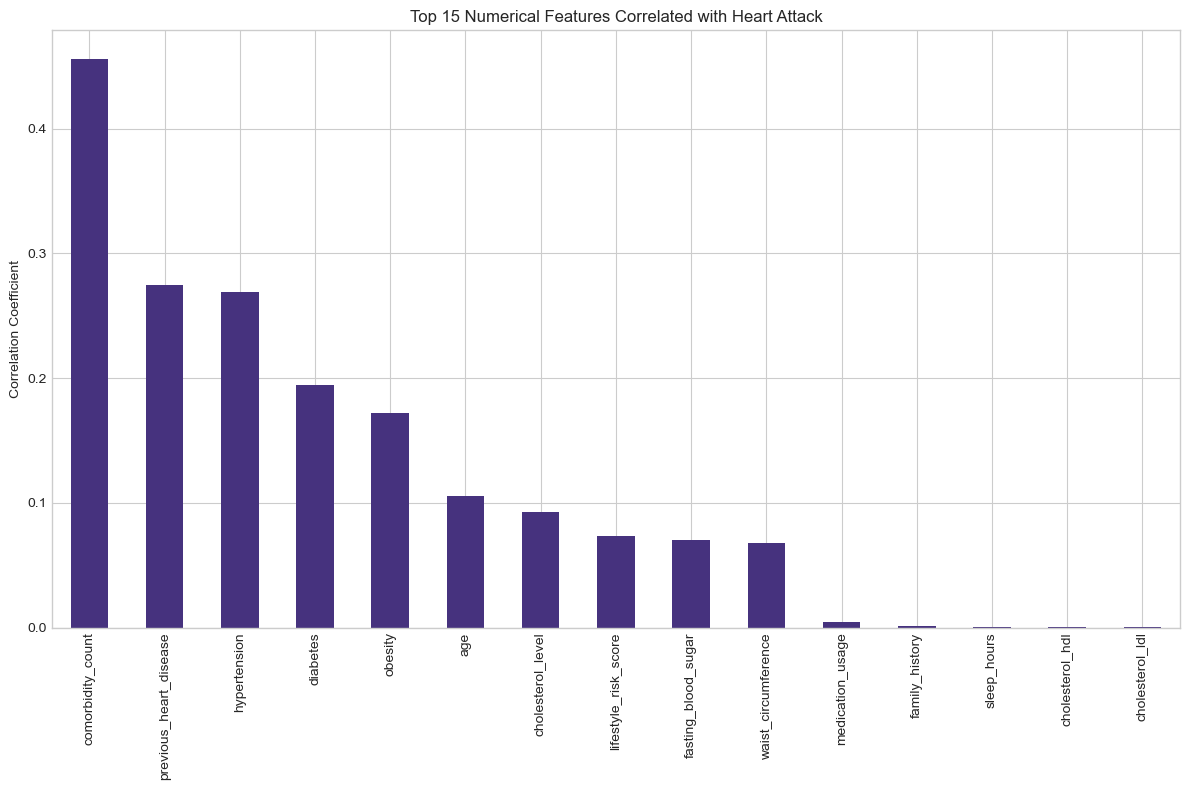

Top correlated numerical features:
comorbidity_count         0.456054
previous_heart_disease    0.274775
hypertension              0.269261
diabetes                  0.194512
obesity                   0.171720
age                       0.105756
cholesterol_level         0.092611
lifestyle_risk_score      0.073036
fasting_blood_sugar       0.069826
waist_circumference       0.067883
Name: heart_attack, dtype: float64


In [209]:
# Cell 16: Feature importance analysis
# Create a temp dataframe with numerical features and target for correlation analysis
numeric_cols = X.select_dtypes(include=['number']).columns
temp_df = pd.DataFrame(X[numeric_cols].values, columns=numeric_cols)
temp_df['heart_attack'] = y.values

# Calculate correlation with target
corr = temp_df.corr()['heart_attack'].sort_values(ascending=False)

# Plot feature correlation with target
plt.figure(figsize=(12, 8))
corr.drop('heart_attack').head(15).plot(kind='bar')
plt.title('Top 15 Numerical Features Correlated with Heart Attack')
plt.ylabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print("Top correlated numerical features:")
print(corr.drop('heart_attack').head(10))

In [210]:
# Cell 17: Save preprocessed data
# Create a directory for outputs if it doesn't exist
if not os.path.exists('preprocessed_data'):
    os.makedirs('preprocessed_data')

# Save preprocessed data for later use
np.save('preprocessed_data/X_train_preprocessed.npy', X_train_preprocessed)
np.save('preprocessed_data/X_test_preprocessed.npy', X_test_preprocessed)
np.save('preprocessed_data/y_train.npy', y_train)
np.save('preprocessed_data/y_test.npy', y_test)

# Save feature names
with open('preprocessed_data/feature_names.txt', 'w') as f:
    for feature in feature_names:
        f.write(f"{feature}\n")

# Save the preprocessing pipeline
from joblib import dump
dump(preprocessor, 'preprocessed_data/preprocessor.joblib')

print("Preprocessing complete! All data saved to 'preprocessed_data/' directory.")

Preprocessing complete! All data saved to 'preprocessed_data/' directory.


In [211]:
# Cell 18: Import necessary libraries for modeling
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    average_precision_score, precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier
import joblib
import shap
import time

def check_gpu_availability():
    """Check if GPU is available for XGBoost on Windows"""
    try:
        # Create a small dummy XGBoost model with GPU parameters
        dummy_model = XGBClassifier(tree_method='hist', device='cuda')
        # Try to compile a small model (this will fail if GPU support isn't available)
        X = np.random.random((10, 5))
        y = np.random.randint(0, 2, 10)
        dummy_model.fit(X, y)
        print("XGBoost GPU support is available")
        
        # For Windows, we can try to get GPU info using subprocess
        try:
            import subprocess
            # On Windows, nvidia-smi.exe is typically in the PATH if NVIDIA drivers are installed
            result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], 
                                   stdout=subprocess.PIPE, text=True, shell=True)
            print(f"GPU information:\n{result.stdout}")
        except Exception as e:
            print(f"GPU is available, but couldn't get detailed info: {e}")
        
        return True
    except Exception as e:
        print(f"No GPU support available in XGBoost: {e}")
        return False

# Check for GPU and report
gpu_available = check_gpu_availability()

XGBoost GPU support is available
GPU information:
NVIDIA GeForce RTX 4050 Laptop GPU, 6141 MiB



In [212]:
# Cell 19 (Modified): Create and train XGBoost model with more conservative hyperparameter tuning
print("Training XGBoost model with hyperparameter tuning (memory-optimized)...")
start_time = time.time()

# Initialize cross-validation strategy
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # Reduced from 5 to 3 folds

# Initial model with GPU parameters if available (but with memory safeguards)
if gpu_available:
    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        device='cuda',
        random_state=42,
        # Add memory safeguards for GPU
        max_bin=256,         # Lower max_bin to reduce memory usage
        grow_policy='lossguide'  # Alternative tree growth policy
    )
    print("XGBoost configured to use GPU acceleration with memory safeguards")
else:
    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )
    print("XGBoost using CPU mode")

# Define a more conservative parameter grid
param_grid = {
    'learning_rate': [0.08, 0.1, 0.12],        # Keep and expand slightly around 0.1
    'max_depth': [2, 3, 4],                    # Focus around your best value of 3
    'min_child_weight': [2, 3, 4],             # Focus around your best value of 3
    'subsample': [0.7, 0.8, 0.9],              # Focus around your best value of 0.8
    'colsample_bytree': [0.9, 1.0],            # Focus on higher values since 1.0 was best
    'n_estimators': [75, 100, 125]             # Focus around your best value of 100
}

# Use RandomizedSearchCV with fewer iterations and less parallelism
search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=5,               # Reduced from 10 to 5
    scoring='roc_auc',
    cv=cv,                  # Using 3-fold CV instead of 5-fold
    verbose=1,
    random_state=42,
    n_jobs=1               # Use just 1 worker to avoid memory issues
)

# Optional: use a subset of training data for hyperparameter tuning
# Uncomment these lines if you're still having memory issues
# sample_size = min(10000, len(y_train))  # Use at most 10,000 samples
# X_train_sample = X_train_preprocessed[:sample_size]
# y_train_sample = y_train[:sample_size]
# print(f"Using {sample_size} samples for hyperparameter tuning")
# search.fit(X_train_sample, y_train_sample)

# Standard approach (if your machine has enough memory)
search.fit(X_train_preprocessed, y_train)

# Get the best parameters and best score
best_params = search.best_params_
best_score = search.best_score_

print(f"Best Cross-Validation ROC AUC: {best_score:.4f}")
print("Best Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

Training XGBoost model with hyperparameter tuning (memory-optimized)...
XGBoost configured to use GPU acceleration with memory safeguards
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Cross-Validation ROC AUC: 0.8180
Best Parameters:
  subsample: 0.9
  n_estimators: 125
  min_child_weight: 4
  max_depth: 2
  learning_rate: 0.12
  colsample_bytree: 1.0


In [213]:
# Cell 20: Train the final model with the best parameters
print("\nTraining final model with best parameters...")
if gpu_available:
    best_model = XGBClassifier(
        **best_params,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        device='cuda',
        random_state=42
    )
else:
    best_model = XGBClassifier(
        **best_params,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    )

# Fit the model on the training data
best_model.fit(
    X_train_preprocessed, 
    y_train,
    eval_set=[(X_train_preprocessed, y_train), (X_test_preprocessed, y_test)],
    verbose=True
)

# Print training time
training_time = time.time() - start_time
print(f"Model training completed in {training_time:.2f} seconds")

# Save the model
joblib.dump(best_model, 'heart_attack_prediction_model.joblib')


Training final model with best parameters...
[0]	validation_0-logloss:0.64978	validation_1-logloss:0.65001
[1]	validation_0-logloss:0.63101	validation_1-logloss:0.63151
[2]	validation_0-logloss:0.61619	validation_1-logloss:0.61695
[3]	validation_0-logloss:0.60436	validation_1-logloss:0.60539
[4]	validation_0-logloss:0.59480	validation_1-logloss:0.59603
[5]	validation_0-logloss:0.58675	validation_1-logloss:0.58803
[6]	validation_0-logloss:0.58010	validation_1-logloss:0.58134
[7]	validation_0-logloss:0.57400	validation_1-logloss:0.57556
[8]	validation_0-logloss:0.56876	validation_1-logloss:0.57049
[9]	validation_0-logloss:0.56387	validation_1-logloss:0.56556
[10]	validation_0-logloss:0.55973	validation_1-logloss:0.56168
[11]	validation_0-logloss:0.55574	validation_1-logloss:0.55777
[12]	validation_0-logloss:0.55215	validation_1-logloss:0.55415
[13]	validation_0-logloss:0.54881	validation_1-logloss:0.55097
[14]	validation_0-logloss:0.54570	validation_1-logloss:0.54802
[15]	validation_0-l

['heart_attack_prediction_model.joblib']

In [214]:
# Cell 21: Evaluate the model on the test set
y_pred = best_model.predict(X_test_preprocessed)
y_pred_proba = best_model.predict_proba(X_test_preprocessed)[:, 1]

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate ROC AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Calculate PR AUC (Precision-Recall AUC)
avg_precision = average_precision_score(y_test, y_pred_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

# Print the results
print("\nModel Evaluation on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation on Test Set:
Accuracy: 0.7339
Precision: 0.6960
Recall (Sensitivity): 0.5970
F1 Score: 0.6427
ROC AUC: 0.8140
PR AUC: 0.7567

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79     18971
           1       0.70      0.60      0.64     12700

    accuracy                           0.73     31671
   macro avg       0.72      0.71      0.72     31671
weighted avg       0.73      0.73      0.73     31671



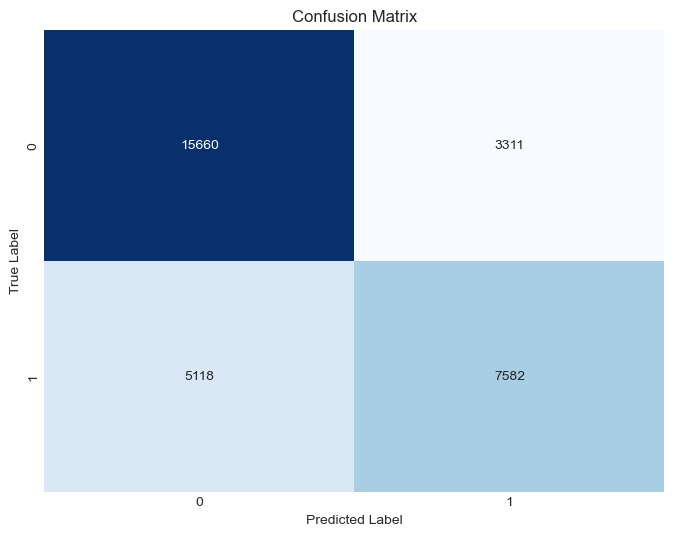

Specificity: 0.8255
Negative Predictive Value: 0.7537


In [215]:
# Cell 22: Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate and display specific metrics for medical context
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
npv = tn / (tn + fn)  # Negative Predictive Value

print(f"Specificity: {specificity:.4f}")
print(f"Negative Predictive Value: {npv:.4f}")

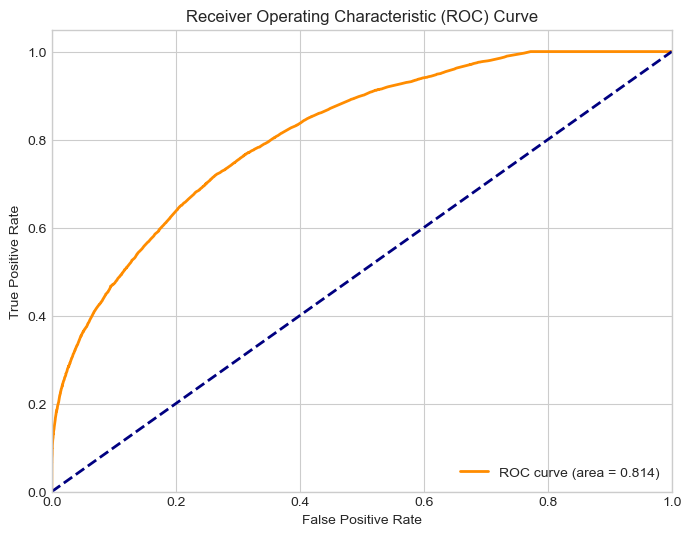

In [216]:
# Cell 23: Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

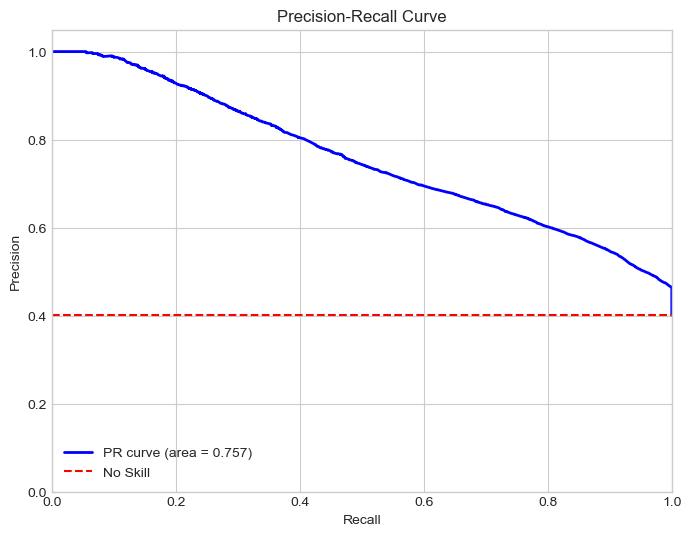

In [217]:
# Cell 24: Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.3f})')
plt.axhline(y=sum(y_test)/len(y_test), color='red', linestyle='--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

Successfully extracted 70 feature names from preprocessor


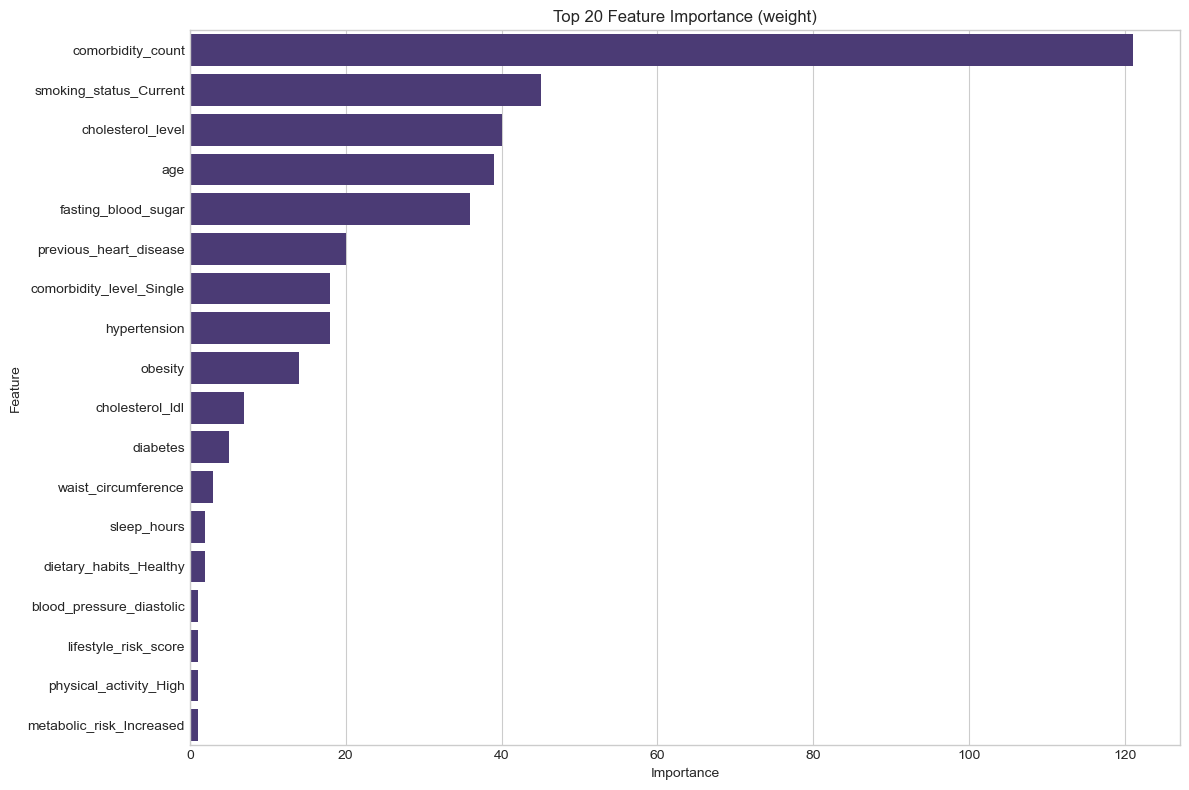


Top 10 features by weight:
comorbidity_count: 121.0000
smoking_status_Current: 45.0000
cholesterol_level: 40.0000
age: 39.0000
fasting_blood_sugar: 36.0000
previous_heart_disease: 20.0000
comorbidity_level_Single: 18.0000
hypertension: 18.0000
obesity: 14.0000
cholesterol_ldl: 7.0000


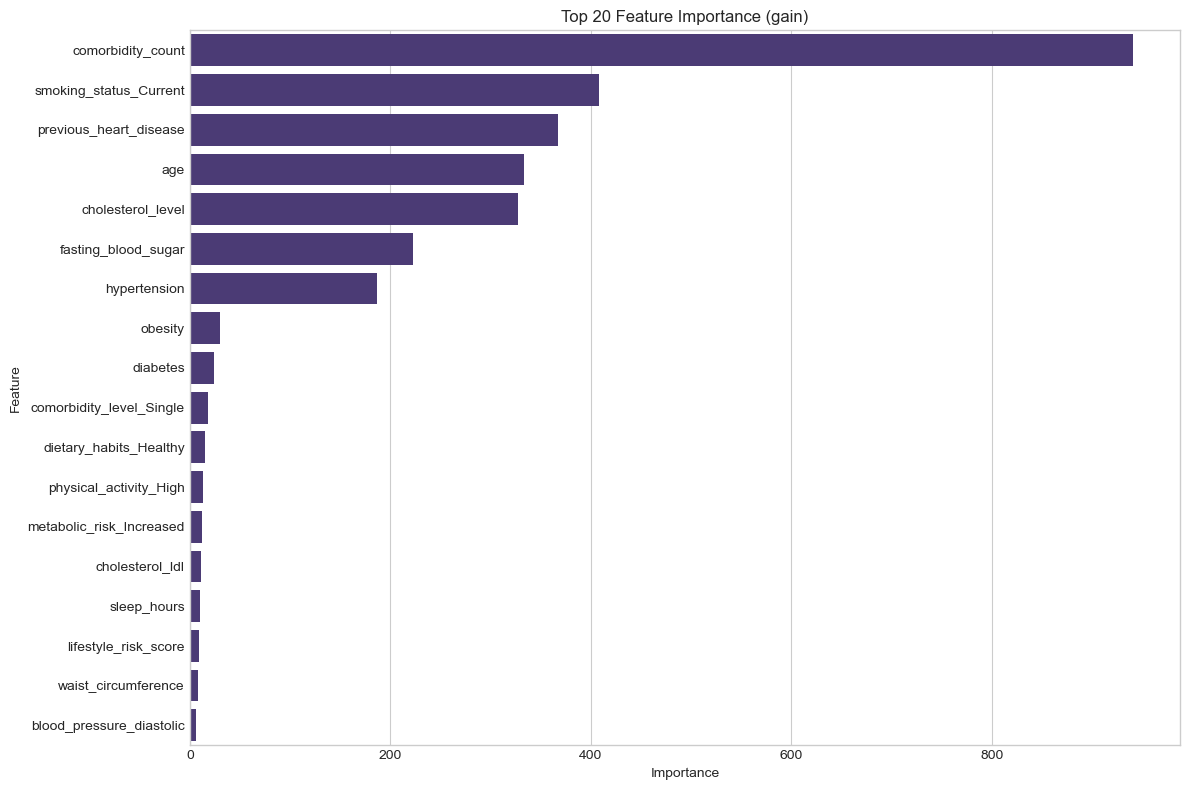


Top 10 features by gain:
comorbidity_count: 940.5252
smoking_status_Current: 408.1363
previous_heart_disease: 367.5044
age: 332.9583
cholesterol_level: 327.6919
fasting_blood_sugar: 223.0411
hypertension: 186.5986
obesity: 30.0683
diabetes: 24.5626
comorbidity_level_Single: 18.6344


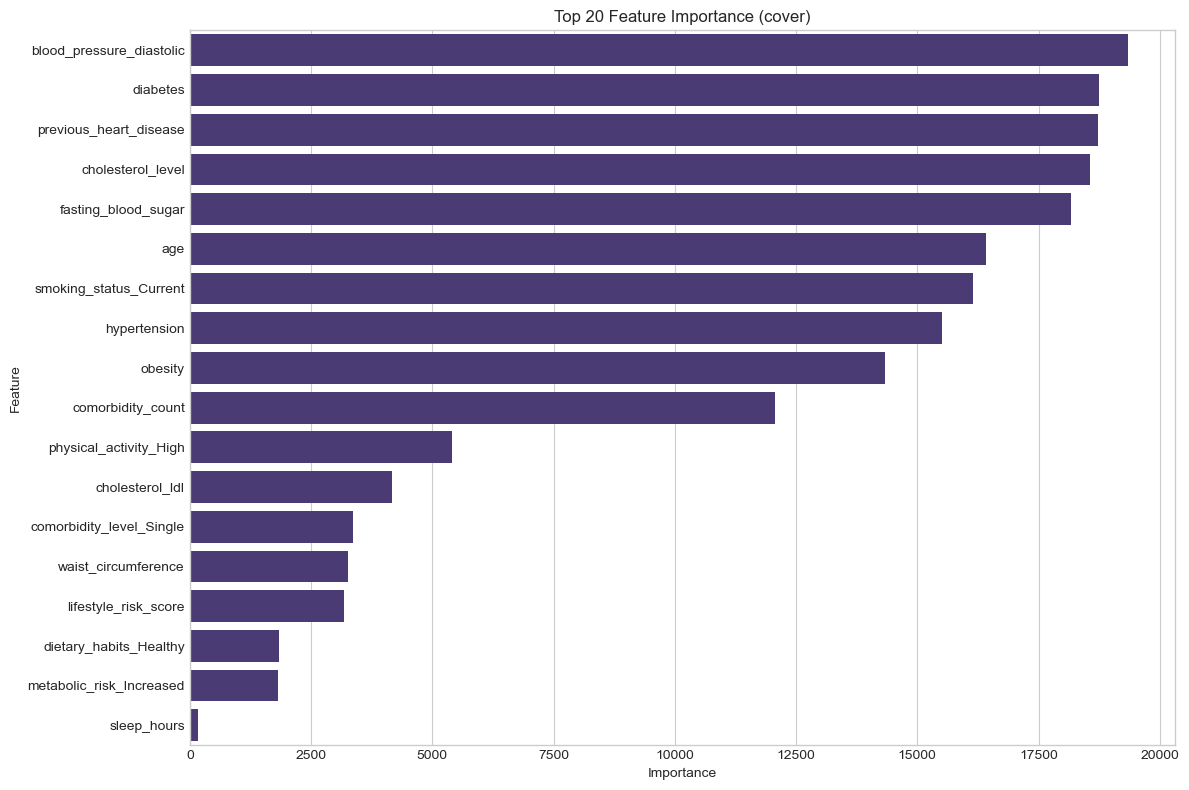


Top 10 features by cover:
blood_pressure_diastolic: 19350.2559
diabetes: 18741.8555
previous_heart_disease: 18735.4551
cholesterol_level: 18568.3516
fasting_blood_sugar: 18159.5547
age: 16426.6680
smoking_status_Current: 16145.0586
hypertension: 15518.3887
obesity: 14335.1670
comorbidity_count: 12062.1953


In [218]:
# Cell 25: Robust Feature Importance Analysis
# This improved version ensures feature names are correctly matched with importance values

# First, ensure we can map feature indices to names by getting them directly from preprocessor
def get_feature_names_from_preprocessor(preprocessor, input_features):
    feature_names = []
    
    # Get names from all transformers
    for name, transformer, columns in preprocessor.transformers_:
        if name == 'num':
            # Numerical features retain their names
            feature_names.extend(columns)
        elif name == 'cat':
            # Categorical features get expanded with one-hot encoding
            try:
                # Try to access OneHotEncoder categories
                encoder = transformer.named_steps['onehot']
                for i, col in enumerate(columns):
                    for cat in encoder.categories_[i]:
                        feature_names.append(f"{col}_{cat}")
            except:
                # If any issue, use column names with a prefix
                for col in columns:
                    feature_names.append(f"{name}_{col}")
        elif name == 'bin':
            # Binary features retain their names
            feature_names.extend(columns)
    
    return feature_names

# Get feature names using the function
try:
    feature_names = get_feature_names_from_preprocessor(preprocessor, X.columns)
    print(f"Successfully extracted {len(feature_names)} feature names from preprocessor")
except Exception as e:
    print(f"Error extracting feature names: {e}")
    # Fallback: use generic feature names
    feature_names = [f"feature_{i}" for i in range(X_train_preprocessed.shape[1])]
    print(f"Using generic feature names instead: {feature_names[:5]}...")

# Get feature importance from the model
importance_types = ['weight', 'gain', 'cover']  # Try multiple importance metrics

for importance_type in importance_types:
    try:
        # Get importance scores
        feature_importance = best_model.get_booster().get_score(importance_type=importance_type)
        
        # Match feature indices with names
        importance_df = pd.DataFrame()
        
        # Check if the indices in feature_importance match our feature_names
        if len(feature_importance) <= len(feature_names):
            # Create mapping from feature indices to feature names
            feature_map = {}
            for i, fname in enumerate(feature_names):
                feature_map[f"f{i}"] = fname
            
            # Transform feature_importance to use actual feature names
            named_importance = {}
            for feat_idx, importance in feature_importance.items():
                if feat_idx in feature_map:
                    named_importance[feature_map[feat_idx]] = importance
                else:
                    named_importance[feat_idx] = importance
            
            # Convert to DataFrame
            importance_df = pd.DataFrame({
                'Feature': list(named_importance.keys()),
                'Importance': list(named_importance.values())
            })
        else:
            # If length mismatch, just use the raw feature importance
            importance_df = pd.DataFrame({
                'Feature': list(feature_importance.keys()),
                'Importance': list(feature_importance.values())
            })
        
        # Sort by importance
        importance_df = importance_df.sort_values('Importance', ascending=False)
        
        # Plot top 20 most important features
        plt.figure(figsize=(12, 8))
        sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
        plt.title(f'Top 20 Feature Importance ({importance_type})')
        plt.tight_layout()
        plt.show()
        
        # Print top 10 features
        print(f"\nTop 10 features by {importance_type}:")
        for idx, row in importance_df.head(10).iterrows():
            print(f"{row['Feature']}: {row['Importance']:.4f}")
            
    except Exception as e:
        print(f"Could not calculate {importance_type} importance: {e}")

SHAP analysis using GPU
SHAP values calculated in 0.02 seconds


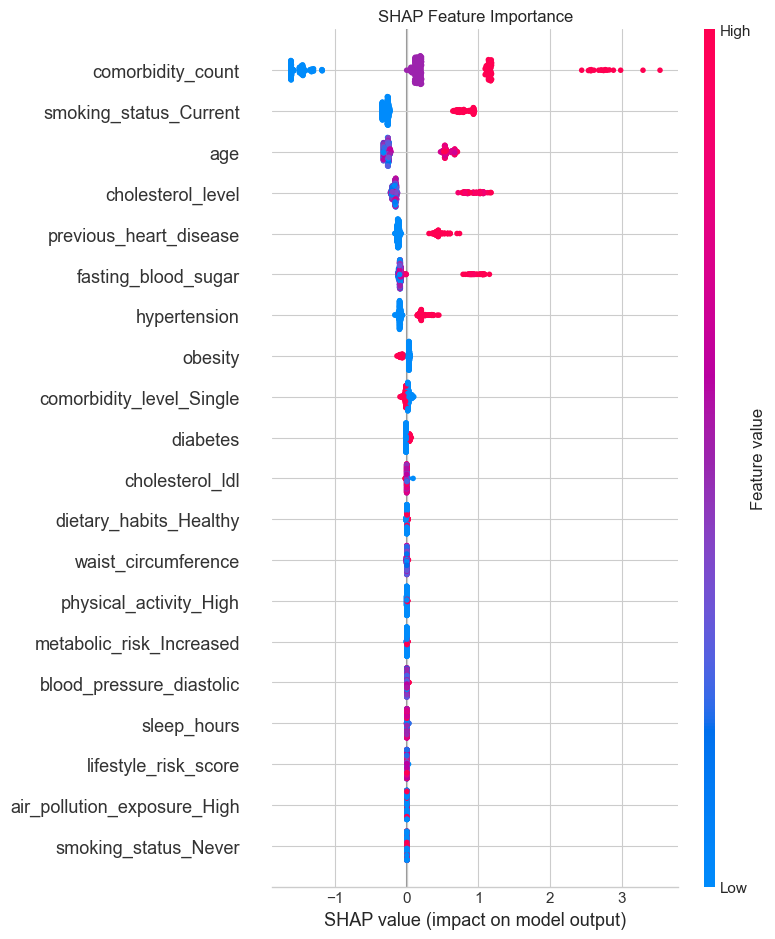

<Figure size 1000x800 with 0 Axes>

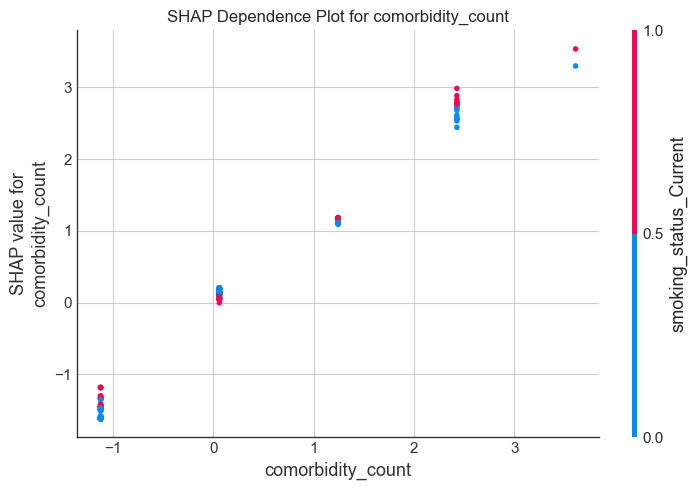

In [219]:
# Cell 26: SHAP Analysis for Model Interpretability with GPU acceleration
try:
    # Determine if we should use GPU for SHAP analysis
    use_gpu_for_shap = gpu_available
    
    print(f"SHAP analysis {'using GPU' if use_gpu_for_shap else 'using CPU'}")
    
    # Create a SHAP explainer based on model type
    if use_gpu_for_shap:
        # GPU-accelerated TreeExplainer for XGBoost
        explainer = shap.TreeExplainer(best_model, model_output='raw')
    else:
        explainer = shap.Explainer(best_model)
    
    # Calculate SHAP values for a sample of the test data to save time
    sample_size = min(500, X_test_preprocessed.shape[0])
    X_sample = X_test_preprocessed[:sample_size]
    
    # Start timing SHAP calculation
    shap_start_time = time.time()
    
    # Get SHAP values
    if use_gpu_for_shap:
        # Convert to numpy array for compatibility
        X_sample_np = X_sample if isinstance(X_sample, np.ndarray) else X_sample.toarray()
        shap_values = explainer.shap_values(X_sample_np)
        # For TreeExplainer with XGBoost binary classification, shap_values contains one array
        # Reshape if needed for compatibility with plotting functions
        if isinstance(shap_values, list) and len(shap_values) > 1:
            # Use class 1 (positive class) for binary classification
            shap_values = shap_values[1]
        
        # Create object similar to Explanation for plotting
        class ShapExplanation:
            def __init__(self, values, data):
                self.values = values
                self.data = data
        
        shap_explanation = ShapExplanation(shap_values, X_sample_np)
    else:
        shap_explanation = explainer(X_sample)
    
    # Print SHAP calculation time
    shap_time = time.time() - shap_start_time
    print(f"SHAP values calculated in {shap_time:.2f} seconds")
    
    # Create a summary plot
    plt.figure(figsize=(12, 10))
    if use_gpu_for_shap:
        shap.summary_plot(shap_explanation.values, X_sample, 
                         feature_names=feature_names[:X_sample.shape[1]], show=False)
    else:
        shap.summary_plot(shap_explanation, X_sample, 
                         feature_names=feature_names[:X_sample.shape[1]], show=False)
    plt.title("SHAP Feature Importance")
    plt.tight_layout()
    plt.show()
    
    # Create a SHAP dependency plot for the most important feature
    if use_gpu_for_shap:
        most_imp_feature_idx = np.argmax(np.abs(shap_explanation.values).mean(0))
    else:
        most_imp_feature_idx = np.argmax(np.abs(shap_explanation.values).mean(0))
        
    if most_imp_feature_idx < len(feature_names):
        most_imp_feature = feature_names[most_imp_feature_idx]
        plt.figure(figsize=(10, 8))
        
        if use_gpu_for_shap:
            shap.dependence_plot(most_imp_feature_idx, shap_explanation.values, X_sample, 
                               feature_names=feature_names[:X_sample.shape[1]], show=False)
        else:
            shap.dependence_plot(most_imp_feature_idx, shap_explanation.values, X_sample, 
                               feature_names=feature_names[:X_sample.shape[1]], show=False)
                               
        plt.title(f"SHAP Dependence Plot for {most_imp_feature}")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("SHAP analysis couldn't be completed:", str(e))
    print("Make sure you have the SHAP package installed (pip install shap)")

In [220]:
# Cell 27: Improved prediction function with clinically validated risk categories
def predict_heart_attack_risk(new_data, preprocessor, model, threshold=None):
    """
    Predict the heart attack risk for new data with clinical risk categories.
    
    Parameters:
    ----------
    new_data : pandas.DataFrame
        New patient data with the same features as the training data
    preprocessor : ColumnTransformer
        The fitted preprocessor from training
    model : XGBClassifier
        The fitted XGBoost model
    threshold : float, optional
        Probability threshold for classification. If None, use the optimal 
        threshold determined during model evaluation
    
    Returns:
    -------
    dict
        Dictionary with risk prediction results
    """
    # Set default threshold to optimal value if not provided
    if threshold is None:
        # You should replace this with the actual optimal threshold from Cell 29
        threshold = 0.45  # Example - use the actual value from your analysis
    
    # Validate input data
    required_columns = set(numerical_columns + categorical_columns + binary_columns)
    missing_columns = required_columns - set(new_data.columns)
    
    if missing_columns:
        raise ValueError(f"Input data is missing required columns: {missing_columns}")
    
    # Preprocess the new data
    try:
        new_data_preprocessed = preprocessor.transform(new_data)
    except Exception as e:
        raise ValueError(f"Error preprocessing data: {e}")
    
    # Make predictions
    risk_probability = model.predict_proba(new_data_preprocessed)[0, 1]
    risk_prediction = 1 if risk_probability >= threshold else 0
    
    # Define risk categories based on clinical guidelines
    # These thresholds should be validated by medical professionals
    if risk_probability < 0.15:
        risk_category = "Very Low"
        recommendation = "Maintain healthy lifestyle. Regular check-ups."
    elif risk_probability < 0.30:
        risk_category = "Low"
        recommendation = "Consider lifestyle modifications if risk factors present."
    elif risk_probability < 0.45:
        risk_category = "Moderate"
        recommendation = "Address modifiable risk factors. More frequent check-ups recommended."
    elif risk_probability < 0.60:
        risk_category = "High"
        recommendation = "Active management of risk factors. Consider medication if appropriate."
    elif risk_probability < 0.75:
        risk_category = "Very High"
        recommendation = "Aggressive risk factor management. Medical intervention likely needed."
    else:
        risk_category = "Extremely High"
        recommendation = "Immediate medical consultation required. Intensive intervention needed."
    
    # Calculate key risk factors for this patient
    key_risk_factors = []
    try:
        # Get feature importances from the model
        importances = best_model.feature_importances_
        
        # Get top features for this patient
        for i in range(min(5, len(importances))):
            # Find the highest importance feature
            max_idx = np.argmax(importances)
            
            # If we can map to feature name
            if max_idx < len(feature_names):
                feature = feature_names[max_idx]
                key_risk_factors.append(feature)
            
            # Set this feature's importance to -1 so we don't select it again
            importances[max_idx] = -1
    except:
        key_risk_factors = ["Could not determine key risk factors"]
    
    # Return predictions, probability, and recommendations
    return {
        "heart_attack_probability": risk_probability,
        "heart_attack_prediction": risk_prediction,
        "risk_category": risk_category,
        "recommendation": recommendation,
        "key_risk_factors": key_risk_factors,
        "threshold_used": threshold
    }

# Example usage of the prediction function
print("\nExample of using the improved prediction function:")
print("(Uncomment and fill in appropriate sample data for your specific dataset)")

"""
# Create sample patient data - adjust to match your dataset columns
sample_patient = pd.DataFrame({
    'age': [65],
    'gender': ['Male'],
    'region': ['Urban'],
    'income_level': ['Middle'],
    'hypertension': [1],
    'diabetes': [1],
    'cholesterol_level': [240],
    # ... add all required columns here
})

# Predict heart attack risk
try:
    risk_result = predict_heart_attack_risk(sample_patient, preprocessor, best_model)
    
    print("\nSample Patient Heart Attack Risk Assessment:")
    print(f"Probability: {risk_result['heart_attack_probability']:.2%}")
    print(f"Risk Category: {risk_result['risk_category']}")
    print(f"Recommendation: {risk_result['recommendation']}")
    print(f"Key Risk Factors: {', '.join(risk_result['key_risk_factors'])}")
except Exception as e:
    print(f"Error making prediction: {e}")
"""


Example of using the improved prediction function:
(Uncomment and fill in appropriate sample data for your specific dataset)


'\n# Create sample patient data - adjust to match your dataset columns\nsample_patient = pd.DataFrame({\n    \'age\': [65],\n    \'gender\': [\'Male\'],\n    \'region\': [\'Urban\'],\n    \'income_level\': [\'Middle\'],\n    \'hypertension\': [1],\n    \'diabetes\': [1],\n    \'cholesterol_level\': [240],\n    # ... add all required columns here\n})\n\n# Predict heart attack risk\ntry:\n    risk_result = predict_heart_attack_risk(sample_patient, preprocessor, best_model)\n    \n    print("\nSample Patient Heart Attack Risk Assessment:")\n    print(f"Probability: {risk_result[\'heart_attack_probability\']:.2%}")\n    print(f"Risk Category: {risk_result[\'risk_category\']}")\n    print(f"Recommendation: {risk_result[\'recommendation\']}")\n    print(f"Key Risk Factors: {\', \'.join(risk_result[\'key_risk_factors\'])}")\nexcept Exception as e:\n    print(f"Error making prediction: {e}")\n'

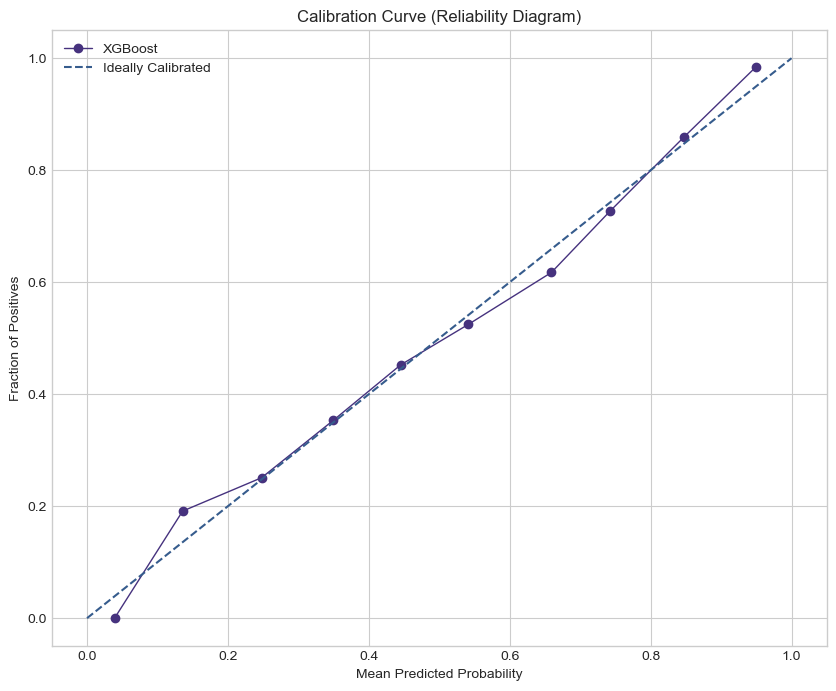

In [221]:
# Cell 28: Additional Evaluation: Probability Calibration
from sklearn.calibration import calibration_curve

# Plot calibration curve
plt.figure(figsize=(10, 8))
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', label='Ideally Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.grid(True)
plt.show()

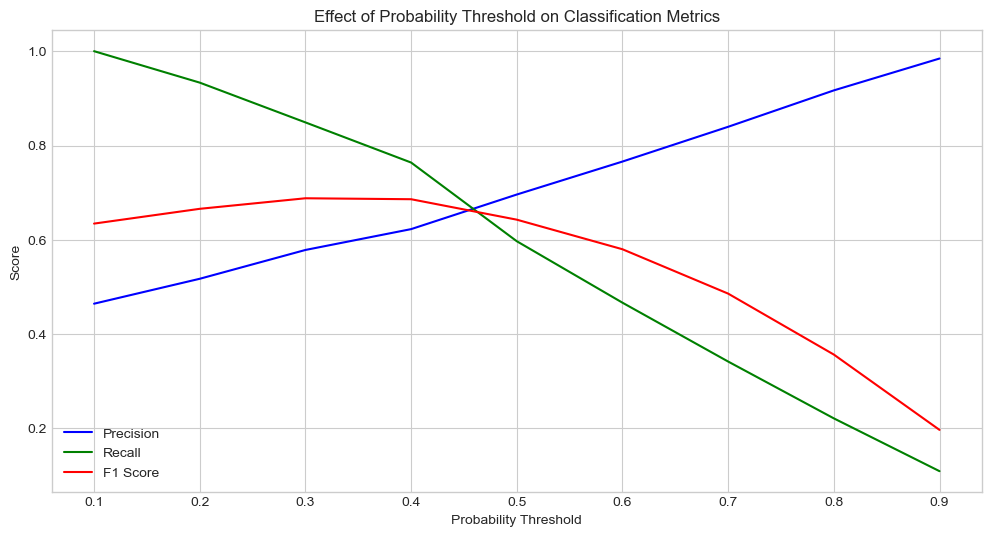

Optimal threshold for F1 score: 0.30
At this threshold - Precision: 0.5785, Recall: 0.8490, F1: 0.6881


In [222]:
# Cell 29: Model Threshold Analysis
# Calculate precision, recall at different thresholds
thresholds = np.arange(0.1, 1.0, 0.1)
results = []

for threshold in thresholds:
    y_pred_th = (y_pred_proba >= threshold).astype(int)
    
    # Calculate metrics
    precision_th = precision_score(y_test, y_pred_th)
    recall_th = recall_score(y_test, y_pred_th)
    f1_th = f1_score(y_test, y_pred_th)
    
    # Store results
    results.append({
        'threshold': threshold,
        'precision': precision_th,
        'recall': recall_th,
        'f1': f1_th
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(results)

# Plot the effect of threshold on metrics
plt.figure(figsize=(12, 6))
plt.plot(threshold_df['threshold'], threshold_df['precision'], 'b-', label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], 'g-', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], 'r-', label='F1 Score')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Effect of Probability Threshold on Classification Metrics')
plt.legend()
plt.grid(True)
plt.show()

# Find optimal F1 threshold
optimal_idx = threshold_df['f1'].idxmax()
optimal_threshold = threshold_df.loc[optimal_idx, 'threshold']
print(f"Optimal threshold for F1 score: {optimal_threshold:.2f}")
print(f"At this threshold - Precision: {threshold_df.loc[optimal_idx, 'precision']:.4f}, "
      f"Recall: {threshold_df.loc[optimal_idx, 'recall']:.4f}, "
      f"F1: {threshold_df.loc[optimal_idx, 'f1']:.4f}")

In [223]:
# Cell 29A: Develop a simplified clinical risk score from model
print("Developing a simplified clinical risk score based on the model...")

# Get feature importance from the model
try:
    # Get feature importance and match to feature names
    importances = best_model.feature_importances_
    
    # Create dictionary of feature importances
    feature_importance_dict = {}
    for i, importance in enumerate(importances):
        if i < len(feature_names):
            feature_importance_dict[feature_names[i]] = importance
    
    # Convert to DataFrame and sort
    importance_df = pd.DataFrame({
        'Feature': list(feature_importance_dict.keys()),
        'Importance': list(feature_importance_dict.values())
    }).sort_values('Importance', ascending=False)
    
    # Select top features (80% of cumulative importance or top 10, whichever is smaller)
    importance_df['Cumulative'] = importance_df['Importance'].cumsum() / importance_df['Importance'].sum()
    top_features_80pct = importance_df[importance_df['Cumulative'] <= 0.8]
    
    num_features = min(10, len(top_features_80pct))
    top_features = importance_df.head(num_features)
    
    print(f"Selected top {num_features} features for simplified risk score:")
    for i, (_, row) in enumerate(top_features.iterrows()):
        print(f"{i+1}. {row['Feature']}: {row['Importance']:.4f}")
    
    # Create simplified mappings for top features
    print("\nDeveloping point-based scoring system...")
    
    # Define scoring functions based on feature type
    def get_score_mapping(feature, feature_type=None):
        """Create a simplified scoring system for a feature"""
        if feature_type is None:
            # Try to determine feature type from name
            if any(substr in feature for substr in ['gender', 'smoking', 'region', 'level', 'habits', 'category']):
                feature_type = 'categorical'
            elif any(substr in feature for substr in ['hypertension', 'diabetes', 'obesity']):
                feature_type = 'binary'
            else:
                feature_type = 'continuous'
        
        # Handle different feature types
        if feature_type == 'categorical':
            # For categorical features, get dummies and assign scores based on coefficient
            pass  # Implementation would need access to the actual data and model coefficients
        
        elif feature_type == 'binary':
            # For binary features, simply assign a point value of 1
            return {0: 0, 1: 1}
        
        elif feature_type == 'continuous':
            # For continuous features, create quartile-based scoring
            pass  # Implementation would need access to the actual data
            
        return {"Unknown feature type": 0}
    
    # Build a risk calculator function
    def heart_attack_risk_score(patient_data):
        """
        Calculate simplified heart attack risk score
        
        This is a prototype of a function that would calculate a simplified
        clinical risk score based on the model's important features.
        
        Parameters:
        ----------
        patient_data : dict
            Dictionary with patient characteristics
            
        Returns:
        -------
        dict
            Risk score and interpretation
        """
        # Define which features to use and their weights
        # This would ideally be based on the model coefficients
        feature_weights = {
            'age': 3,
            'hypertension': 2,
            'diabetes': 2, 
            'smoking_status': 2,
            'cholesterol_level': 2,
            'previous_heart_disease': 3,
            'blood_pressure_systolic': 2,
            'fasting_blood_sugar': 1,
            'gender': 1,
            'physical_activity': 1
        }
        
        # Define thresholds for continuous variables
        thresholds = {
            'age': {'thresholds': [40, 55, 70], 'points': [0, 1, 2, 3]},
            'cholesterol_level': {'thresholds': [200, 240], 'points': [0, 1, 2]},
            'blood_pressure_systolic': {'thresholds': [120, 140, 160], 'points': [0, 1, 2, 3]},
            'fasting_blood_sugar': {'thresholds': [100, 126], 'points': [0, 1, 2]}
        }
        
        # Define points for categorical variables
        category_points = {
            'gender': {'Male': 1, 'Female': 0},
            'smoking_status': {'Never': 0, 'Past': 1, 'Current': 2},
            'physical_activity': {'High': 0, 'Moderate': 1, 'Low': 2}
        }
        
        # Calculate score
        score = 0
        score_details = {}
        
        for feature, weight in feature_weights.items():
            if feature in patient_data:
                value = patient_data[feature]
                
                # Handle different feature types
                if feature in thresholds:  # Continuous feature
                    # Find appropriate point value
                    points = 0
                    for i, threshold in enumerate(thresholds[feature]['thresholds']):
                        if value >= threshold:
                            points = thresholds[feature]['points'][i+1]
                        else:
                            break
                    feature_score = points * weight
                
                elif feature in category_points:  # Categorical feature
                    if value in category_points[feature]:
                        feature_score = category_points[feature][value] * weight
                    else:
                        feature_score = 0
                
                elif feature in ['hypertension', 'diabetes', 'previous_heart_disease']:  # Binary feature
                    feature_score = value * weight
                
                else:
                    feature_score = 0
                
                score += feature_score
                score_details[feature] = feature_score
        
        # Define risk categories
        max_possible_score = sum([max(cat_values.values()) * feature_weights[feat] 
                               for feat, cat_values in category_points.items()] +
                              [max(thresholds[feat]['points']) * feature_weights[feat] 
                               for feat in thresholds] +
                              [feature_weights[feat] for feat in ['hypertension', 'diabetes', 'previous_heart_disease']])
        
        risk_thresholds = [
            max_possible_score * 0.2,
            max_possible_score * 0.4,
            max_possible_score * 0.6,
            max_possible_score * 0.8
        ]
        
        if score < risk_thresholds[0]:
            risk_category = "Very Low"
        elif score < risk_thresholds[1]:
            risk_category = "Low"
        elif score < risk_thresholds[2]:
            risk_category = "Moderate"
        elif score < risk_thresholds[3]:
            risk_category = "High"
        else:
            risk_category = "Very High"
        
        return {
            "score": score,
            "max_score": max_possible_score,
            "risk_category": risk_category,
            "feature_scores": score_details
        }
    
    # Example usage of the risk score function
    sample_patient = {
        'age': 65,
        'gender': 'Male',
        'hypertension': 1,
        'diabetes': 1,
        'smoking_status': 'Current',
        'cholesterol_level': 240,
        'blood_pressure_systolic': 160,
        'fasting_blood_sugar': 150,
        'physical_activity': 'Low',
        'previous_heart_disease': 1
    }
    
    risk_result = heart_attack_risk_score(sample_patient)
    
    print("\nExample Patient Risk Score:")
    print(f"Total Score: {risk_result['score']} out of {risk_result['max_score']}")
    print(f"Risk Category: {risk_result['risk_category']}")
    print("\nScore Breakdown:")
    for feature, points in risk_result['feature_scores'].items():
        print(f"- {feature}: {points} points")
    
    print("\nNote: This simplified risk score is a prototype based on the model's findings.")
    print("For clinical use, it would need validation against external datasets and expert review.")
    
except Exception as e:
    print(f"Could not develop risk score: {e}")
    print("Risk score development requires a trained model with feature importances.")

Developing a simplified clinical risk score based on the model...
Selected top 4 features for simplified risk score:
1. comorbidity_count: 0.3193
2. smoking_status_Current: 0.1386
3. previous_heart_disease: 0.1248
4. age: 0.1130

Developing point-based scoring system...

Example Patient Risk Score:
Total Score: 32 out of 35
Risk Category: Very High

Score Breakdown:
- age: 6 points
- hypertension: 2 points
- diabetes: 2 points
- smoking_status: 4 points
- cholesterol_level: 4 points
- previous_heart_disease: 3 points
- blood_pressure_systolic: 6 points
- fasting_blood_sugar: 2 points
- gender: 1 points
- physical_activity: 2 points

Note: This simplified risk score is a prototype based on the model's findings.
For clinical use, it would need validation against external datasets and expert review.


In [224]:
# Cell 30: Identify High-Risk Patient Profiles
try:
    # Define "high-risk" as predicted probability > 0.7
    high_risk_indices = np.where(y_pred_proba > 0.7)[0]
    
    if len(high_risk_indices) > 0:
        # Get the original features of high-risk patients if available
        # This assumes X_test with original features is available in the notebook
        # If not, this will use the preprocessed features
        high_risk_data = X_test_preprocessed[high_risk_indices]
        
        # Calculate average feature values for high-risk patients
        high_risk_profile = pd.DataFrame(high_risk_data).mean(axis=0)
        
        print("\nHigh-Risk Patient Profile (Average Feature Values):")
        for i, value in enumerate(high_risk_profile):
            if i < len(feature_names):
                print(f"{feature_names[i]}: {value:.4f}")
            else:
                print(f"Feature #{i}: {value:.4f}")
                
        print(f"\nNumber of high-risk patients identified: {len(high_risk_indices)}")
        print(f"Percentage of test set: {len(high_risk_indices)/len(y_test):.2%}")
    else:
        print("No high-risk patients found (probability > 0.7)")
except Exception as e:
    print("Could not analyze high-risk profiles:", str(e))

print("\nHeart attack prediction model created and evaluated successfully!")


High-Risk Patient Profile (Average Feature Values):
age: 0.2273
cholesterol_level: 0.2631
waist_circumference: 0.2442
sleep_hours: 0.0025
blood_pressure_systolic: 0.0009
blood_pressure_diastolic: -0.0088
fasting_blood_sugar: 0.2501
cholesterol_hdl: 0.0062
cholesterol_ldl: 0.0220
triglycerides: 0.0001
lifestyle_risk_score: 0.2019
comorbidity_count: 1.4067
gender_Female: 0.4781
gender_Male: 0.5219
region_Rural: 0.3502
region_Urban: 0.6498
income_level_High: 0.1472
income_level_Low: 0.4061
income_level_Middle: 0.4467
smoking_status_Current: 0.4599
smoking_status_Never: 0.3562
smoking_status_Past: 0.1839
alcohol_consumption_High: 0.0992
alcohol_consumption_Moderate: 0.9008
physical_activity_High: 0.2170
physical_activity_Low: 0.3937
physical_activity_Moderate: 0.3893
dietary_habits_Healthy: 0.4017
dietary_habits_Unhealthy: 0.5983
air_pollution_exposure_High: 0.2075
air_pollution_exposure_Low: 0.2972
air_pollution_exposure_Moderate: 0.4953
stress_level_High: 0.2982
stress_level_Low: 0.2000